In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

# Base directory
base_dir = r"C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data"

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
# Add Week 1 results to existing DataFrames
weekly_results = [week1_results, week2_results]  # Add as many weeks as needed

for week_idx, week_results in enumerate(weekly_results, start=1):
    for func_name, (x_vals, y_val) in week_results.items():
        df = functions_data[func_name]
        
        # Combine input values and output value in the correct order
        new_row = list(x_vals) + [y_val]
        
        # Append new row
        df.loc[len(df)] = new_row
        
        # Update the dictionary
        functions_data[func_name] = df

# Check shapes to confirm the new row was added
for name, df in functions_data.items():
    print(f"{name}: {df.shape}")




f1: (12, 3)
f2: (12, 3)
f3: (17, 4)
f4: (32, 5)
f5: (22, 5)
f6: (22, 6)
f7: (32, 7)
f8: (42, 9)


In [6]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -

In [7]:
import pandas as pd

print("=== Missing Data Summary for All Functions ===\n")

for name, df in functions_data.items():
    print(f"{name}:")
    # Count missing values per column
    missing_per_col = df.isnull().sum()
    # Total missing values
    total_missing = df.isnull().sum().sum()
    
    display(missing_per_col)
    print(f"Total missing values in {name}: {total_missing}\n")

=== Missing Data Summary for All Functions ===

f1:


X1    0
X2    0
y1    0
dtype: int64

Total missing values in f1: 0

f2:


X1    0
X2    0
y1    0
dtype: int64

Total missing values in f2: 0

f3:


...

Total missing values in f6: 0

f7:


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
y1    0
dtype: int64

Total missing values in f7: 0

f8:


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
y1    0
dtype: int64

Total missing values in f8: 0



In [8]:
for name, df in functions_data.items():
    print(f"\n=== {name} Full Data ===")
    display(df)  # Display the entire DataFrame


=== f1 Full Data ===


,X1,X2,y1
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48



=== f2 Full Data ===


,X1,X2,y1
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205



=== f3 Full Data ===


...

,X1,X2,X3,X4,X5,y1
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116



=== f7 Full Data ===


,X1,X2,X3,X4,X5,X6,y1
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565



=== f8 Full Data ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [9]:
for name, df in functions_data.items():
    print(f"\n=== {name} Summary Statistics ===")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





=== f1 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,12.0,0.590197,0.253564,0.082507,3.876788e-01,6.667661e-01,7.953503e-01,8.838898e-01
X2,12.0,0.505355,0.313152,0.002800,2.354373e-01,6.242615e-01,7.404898e-01,8.798981e-01
y1,12.0,-0.000301,0.001041,-0.003606,-5.222733e-92,6.793724e-80,6.337511e-41,7.710875e-16



=== f2 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,12.0,0.578300,0.252281,0.142699,0.414062,0.566344,0.738296,0.999500
X2,12.0,0.490045,0.359410,0.001800,0.191393,0.517012,0.773637,0.999446
y1,12.0,0.179214,0.246204,-0.079755,-0.026799,0.126857,0.325641,0.611205



=== f3 Summary Statistics ===


...

,count,mean,std,min,25%,50%,75%,max
X1,22.0,0.544784,0.292143,0.021735,0.285090,0.624060,0.767364,0.957740
X2,22.0,0.521900,0.302227,0.001300,0.289212,0.482210,0.801032,0.931871
X3,22.0,0.490052,0.315128,0.016523,0.225921,0.479642,0.726444,0.978806
X4,22.0,0.560530,0.279642,0.045613,0.364471,0.663673,0.748747,0.961656
X5,22.0,0.400568,0.292651,0.004911,0.118346,0.415394,0.610725,0.892819
y1,22.0,-1.416359,0.507731,-2.571170,-1.700504,-1.332899,-1.161077,-0.564857



=== f7 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,32.0,0.504175,0.311778,0.008500,0.190433,0.542122,0.792342,0.942451
X2,32.0,0.409435,0.264204,0.011813,0.202224,0.387701,0.564890,0.949047
X3,32.0,0.400234,0.317725,0.003635,0.093993,0.318555,0.691529,0.924571
X4,32.0,0.492173,0.313194,0.073659,0.218109,0.435183,0.813672,0.961017
X5,32.0,0.467829,0.306932,0.014944,0.191255,0.457732,0.718674,0.998655
X6,32.0,0.495995,0.276150,0.051100,0.321010,0.552544,0.716003,0.980800
y1,32.0,0.230628,0.314679,0.002701,0.018124,0.078631,0.325018,1.364968



=== f8 Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
X1,42.0,0.523563,0.307108,0.009077,0.297973,0.519375,0.788620,0.985945
X2,42.0,0.476829,0.315184,0.003419,0.185438,0.540389,0.738236,0.973980
X3,42.0,0.501769,0.284485,0.022929,0.289938,0.451130,0.729167,0.998885
X4,42.0,0.419818,0.261662,0.009043,0.178523,0.438626,0.656450,0.902986
X5,42.0,0.469967,0.274803,0.009649,0.242101,0.421839,0.712203,0.986902
X6,42.0,0.466369,0.272874,0.022113,0.247226,0.427611,0.702532,0.990244
X7,42.0,0.573969,0.258524,0.035909,0.416367,0.596949,0.764873,0.992914
X8,42.0,0.505271,0.274866,0.041956,0.300059,0.525116,0.725448,0.988755
y1,42.0,7.878365,0.989882,5.592193,7.302627,7.940817,8.524545,9.835132



=== f1 Pearson Correlation Matrix ===


,X1,X2,y1
X1,1.000000,0.141832,-0.074415
X2,0.141832,1.000000,-0.177165
y1,-0.074415,-0.177165,1.000000


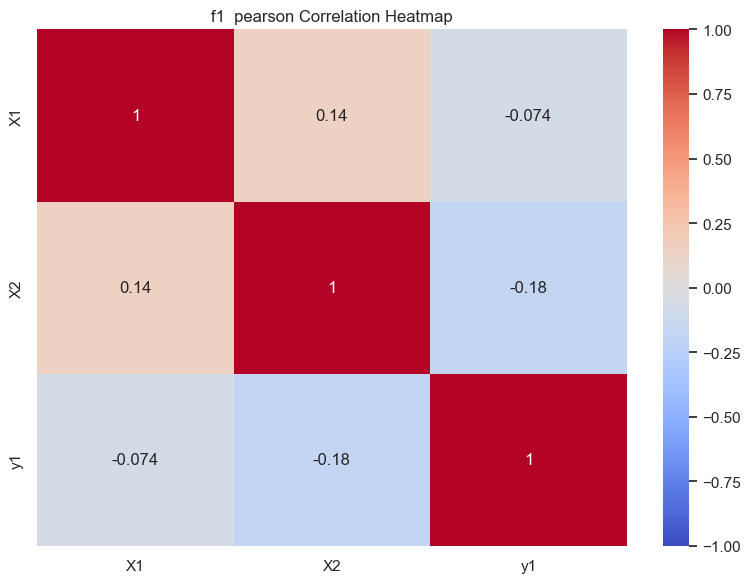


=== f2 Pearson Correlation Matrix ===


,X1,X2,y1
X1,1.000000,0.184591,0.377120
X2,0.184591,1.000000,0.269563
y1,0.377120,0.269563,1.000000


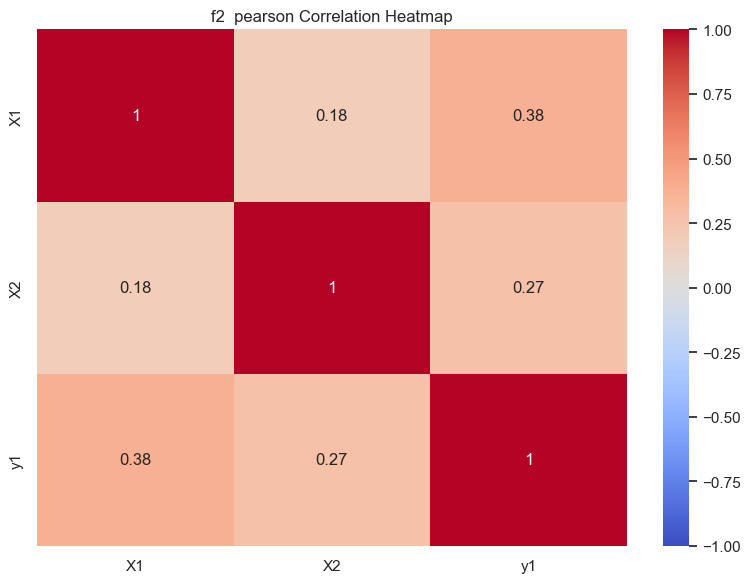


=== f3 Pearson Correlation Matrix ===


,X1,X2,X3,y1
X1,1.000000,0.088774,0.011429,0.072440
X2,0.088774,1.000000,-0.398785,0.240111
X3,0.011429,-0.398785,1.000000,-0.566439
y1,0.072440,0.240111,-0.566439,1.000000


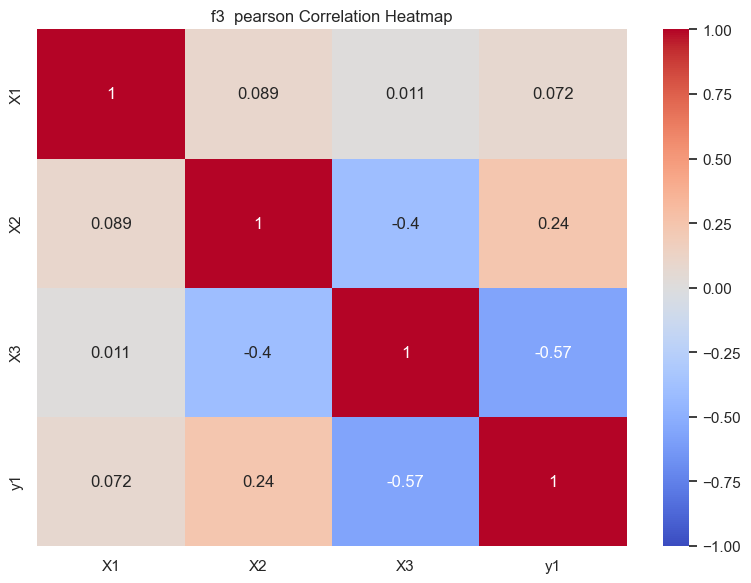


=== f4 Pearson Correlation Matrix ===


,X1,X2,X3,X4,y1
X1,1.000000,0.253728,0.252987,0.189701,-0.494679
X2,0.253728,1.000000,-0.068019,0.189663,-0.488063
X3,0.252987,-0.068019,1.000000,-0.152592,-0.109511
X4,0.189701,0.189663,-0.152592,1.000000,-0.481951
y1,-0.494679,-0.488063,-0.109511,-0.481951,1.000000


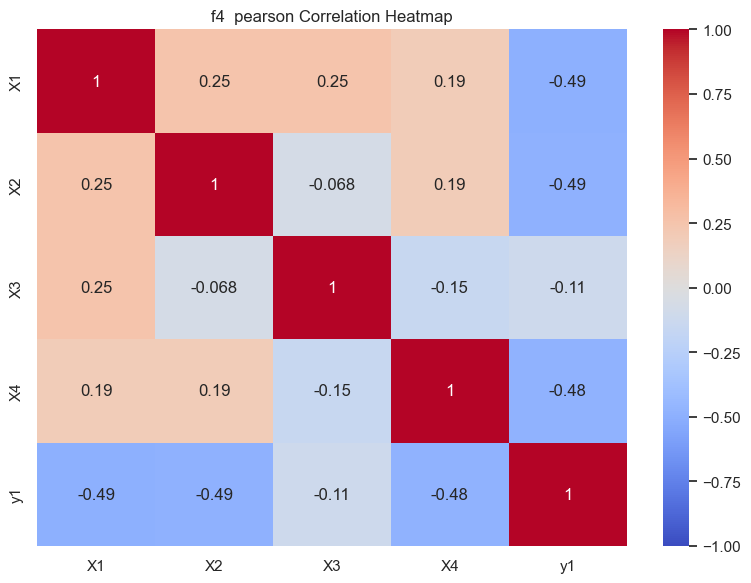


=== f5 Pearson Correlation Matrix ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.282480,-0.208516,0.228817,-0.046807
X2,-0.282480,1.000000,0.054412,0.138720,0.371532
X3,-0.208516,0.054412,1.000000,-0.081682,0.536430
X4,0.228817,0.138720,-0.081682,1.000000,0.453288
y1,-0.046807,0.371532,0.536430,0.453288,1.000000


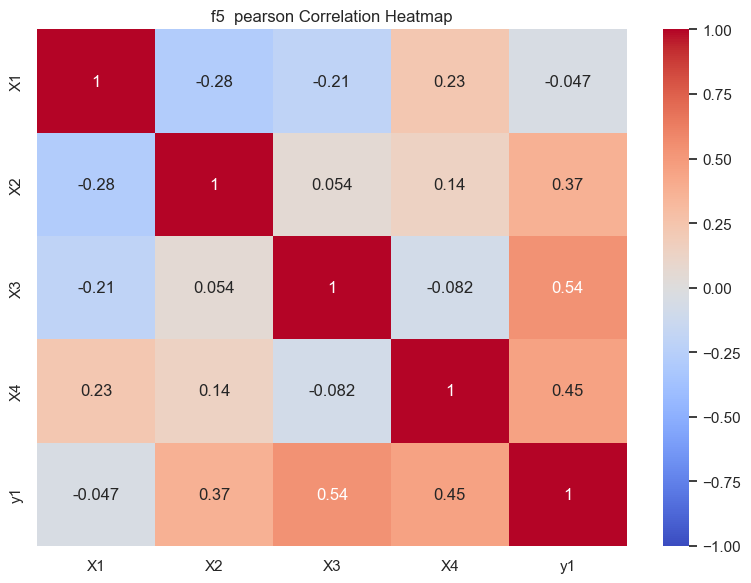


=== f6 Pearson Correlation Matrix ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.218893,-0.083985,0.152819,-0.408737,0.070539
X2,-0.218893,1.000000,0.143667,-0.253947,0.301695,-0.469664
X3,-0.083985,0.143667,1.000000,0.240708,-0.170957,0.323206
X4,0.152819,-0.253947,0.240708,1.000000,-0.268735,0.586956
X5,-0.408737,0.301695,-0.170957,-0.268735,1.000000,-0.614728
y1,0.070539,-0.469664,0.323206,0.586956,-0.614728,1.000000


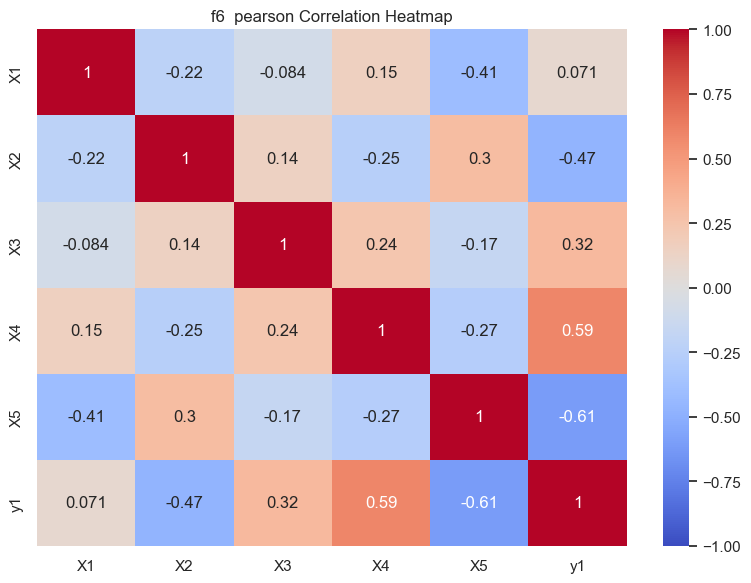


=== f7 Pearson Correlation Matrix ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.010138,-0.124663,-0.106112,0.005326,-0.502430,-0.413363
X2,0.010138,1.000000,0.060234,0.110990,0.336823,0.113175,-0.026002
X3,-0.124663,0.060234,1.000000,0.182898,-0.253208,0.015282,0.100045
X4,-0.106112,0.110990,0.182898,1.000000,0.065650,-0.003390,-0.125007
X5,0.005326,0.336823,-0.253208,0.065650,1.000000,0.063144,-0.390981
X6,-0.502430,0.113175,0.015282,-0.003390,0.063144,1.000000,0.382456
y1,-0.413363,-0.026002,0.100045,-0.125007,-0.390981,0.382456,1.000000


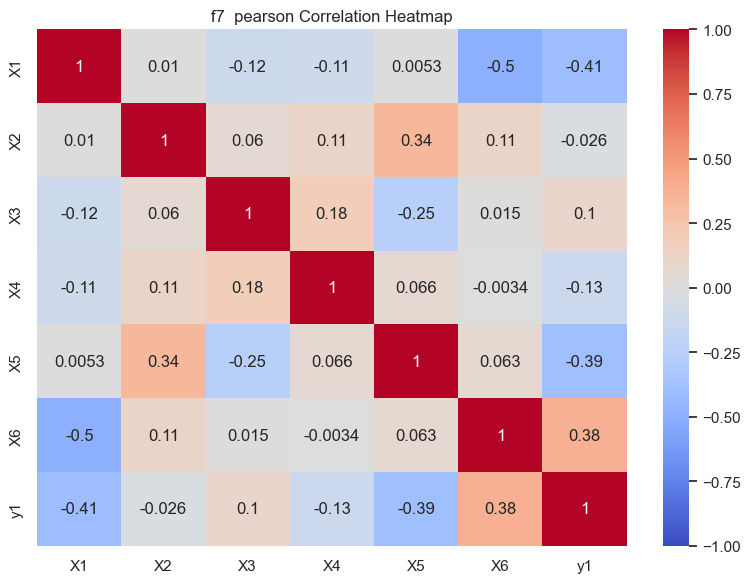


=== f8 Pearson Correlation Matrix ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.144687,0.066531,0.130041,0.278218,0.148197,0.170949,0.135544,-0.631447
X2,0.144687,1.000000,0.093601,-0.177873,0.085183,0.010199,-0.141994,-0.256556,-0.236762
X3,0.066531,0.093601,1.000000,0.080934,-0.034485,-0.208423,-0.143537,0.016414,-0.651583
X4,0.130041,-0.177873,0.080934,1.000000,-0.039644,-0.116487,-0.059952,0.390581,-0.139647
X5,0.278218,0.085183,-0.034485,-0.039644,1.000000,0.090850,0.202144,0.056270,-0.162580
X6,0.148197,0.010199,-0.208423,-0.116487,0.090850,1.000000,-0.023223,0.061311,0.080432
X7,0.170949,-0.141994,-0.143537,-0.059952,0.202144,-0.023223,1.000000,-0.125199,-0.325193
X8,0.135544,-0.256556,0.016414,0.390581,0.056270,0.061311,-0.125199,1.000000,0.035330
y1,-0.631447,-0.236762,-0.651583,-0.139647,-0.162580,0.080432,-0.325193,0.035330,1.000000


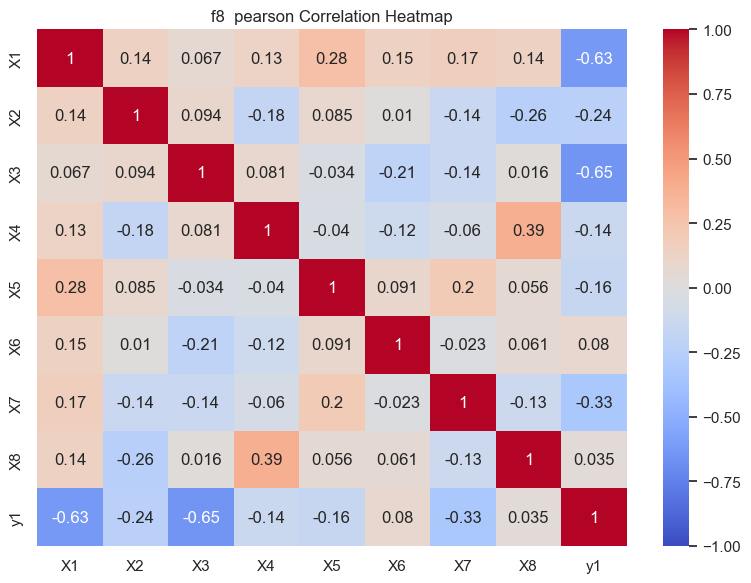

In [10]:
for name, df in functions_data.items():

    print(f"\n=== {name} Pearson Correlation Matrix ===")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

## Pearson Correlation Analysis (f1–f8)

## Observations

- **f1:** X1 and X2 moderately correlated (0.329), y1 weakly negatively correlated with both inputs.  
- **f2:** X1 strongly positively correlated with y1 (0.687) → X1 is likely an important predictor.  
- **f3:** X3 strongly negatively correlated with y1 (-0.530) → decreasing X3 increases y1.  
- **f4:** Multiple moderate negative correlations with y1 → complex relationships.  
- **f5:** X2, X3 moderately positively correlated with y1 → moderate predictors.  
- **f6:** X4 and y1 (0.561), X5 and y1 (-0.609) → strong predictors.  
- **f7:** Most correlations weak, except X1 (-0.356) → moderate predictor.  
- **f8:** X1 (-0.630) → very strong negative effect on y1.  

## Takeaways

- Strongest predictors can be inferred from high absolute `r` values with y1.  
- f matrices with many weak correlations → relationships might be non-linear or influenced by multiple variables.



=== f1 — Spearman Correlation ===


,X1,X2,y1
X1,1.000000,-0.069930,0.286713
X2,-0.069930,1.000000,0.615385
y1,0.286713,0.615385,1.000000


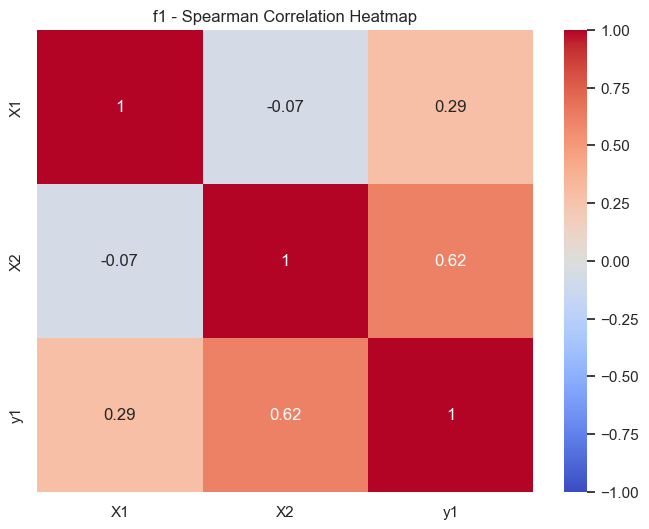


=== f2 — Spearman Correlation ===


,X1,X2,y1
X1,1.000000,0.181818,0.307692
X2,0.181818,1.000000,0.258741
y1,0.307692,0.258741,1.000000


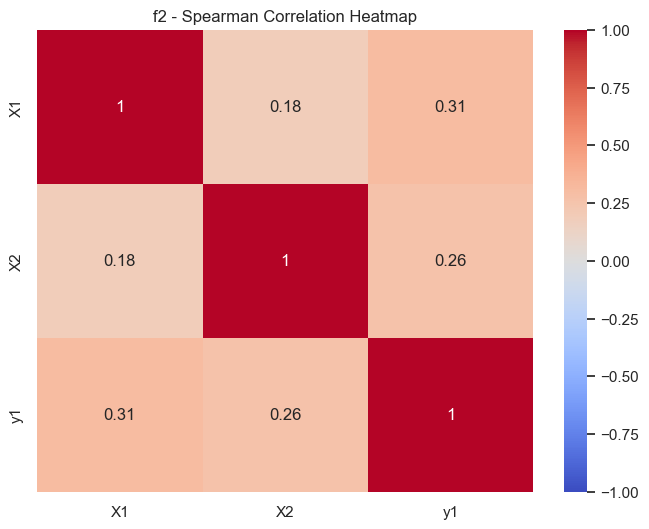


=== f3 — Spearman Correlation ===


,X1,X2,X3,y1
X1,1.000000,0.164216,-0.127451,-0.031863
X2,0.164216,1.000000,-0.379902,0.350490
X3,-0.127451,-0.379902,1.000000,-0.308824
y1,-0.031863,0.350490,-0.308824,1.000000


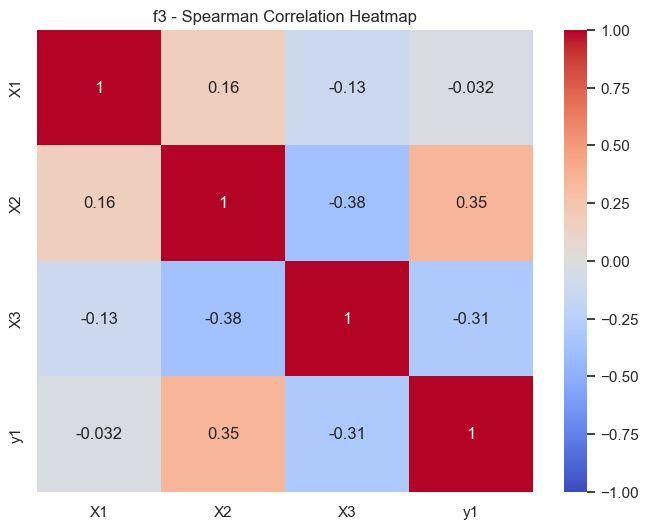


=== f4 — Spearman Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,0.259897,0.236804,0.189883,-0.526026
X2,0.259897,1.000000,-0.028959,0.164589,-0.462610
X3,0.236804,-0.028959,1.000000,-0.171554,-0.157991
X4,0.189883,0.164589,-0.171554,1.000000,-0.423387
y1,-0.526026,-0.462610,-0.157991,-0.423387,1.000000


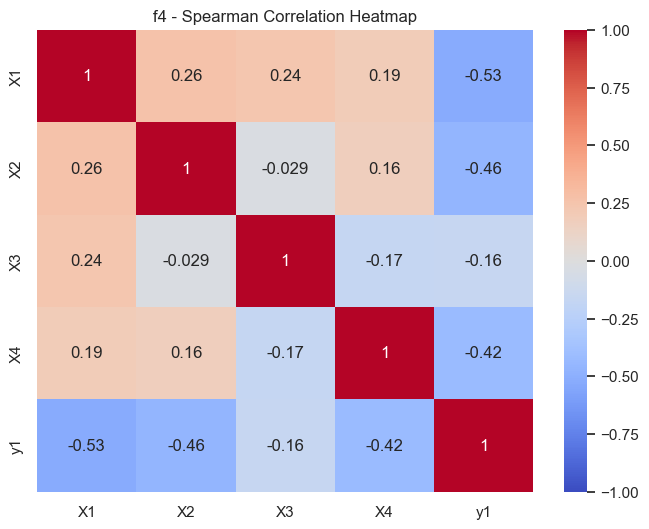


=== f5 — Spearman Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.333710,-0.181254,0.215133,-0.182383
X2,-0.333710,1.000000,0.154150,0.127047,0.317899
X3,-0.181254,0.154150,1.000000,-0.090909,0.452287
X4,0.215133,0.127047,-0.090909,1.000000,0.465839
y1,-0.182383,0.317899,0.452287,0.465839,1.000000


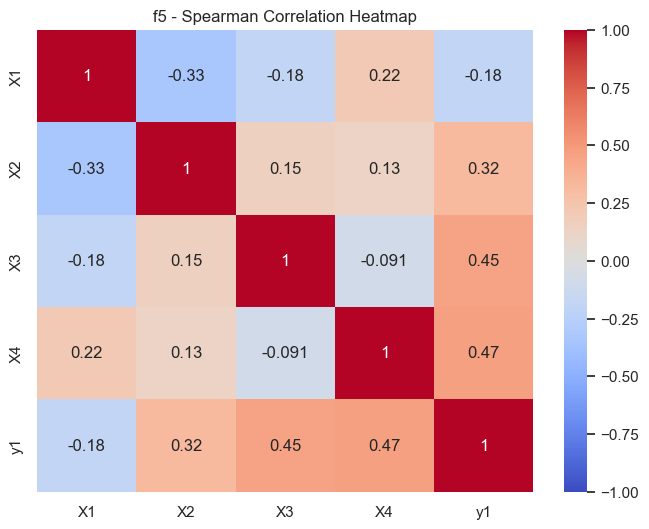


=== f6 — Spearman Correlation ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.169960,-0.057030,0.185771,-0.416149,-0.031056
X2,-0.169960,1.000000,0.067194,-0.210615,0.211745,-0.366460
X3,-0.057030,0.067194,1.000000,0.312253,-0.237719,0.302089
X4,0.185771,-0.210615,0.312253,1.000000,-0.305477,0.607002
X5,-0.416149,0.211745,-0.237719,-0.305477,1.000000,-0.596838
y1,-0.031056,-0.366460,0.302089,0.607002,-0.596838,1.000000


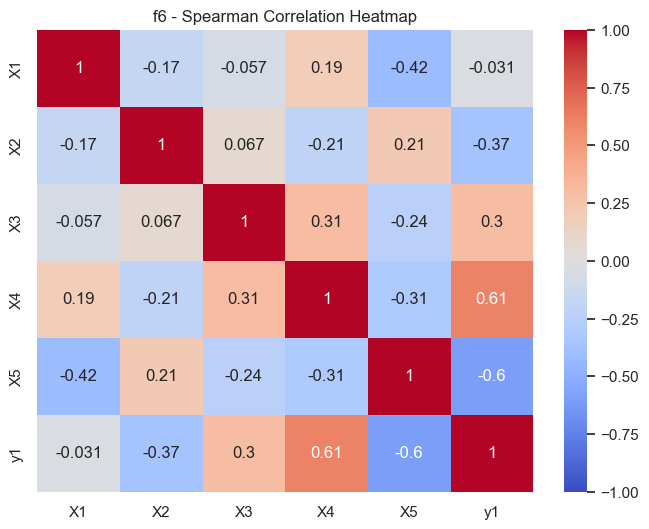


=== f7 — Spearman Correlation ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.057185,-0.105205,-0.085044,-0.041789,-0.461510,-0.364370
X2,-0.057185,1.000000,0.043622,0.161657,0.340176,0.107405,-0.146261
X3,-0.105205,0.043622,1.000000,0.131598,-0.272361,0.053152,0.256598
X4,-0.085044,0.161657,0.131598,1.000000,0.049487,0.029692,-0.144062
X5,-0.041789,0.340176,-0.272361,0.049487,1.000000,0.050220,-0.449780
X6,-0.461510,0.107405,0.053152,0.029692,0.050220,1.000000,0.251833
y1,-0.364370,-0.146261,0.256598,-0.144062,-0.449780,0.251833,1.000000


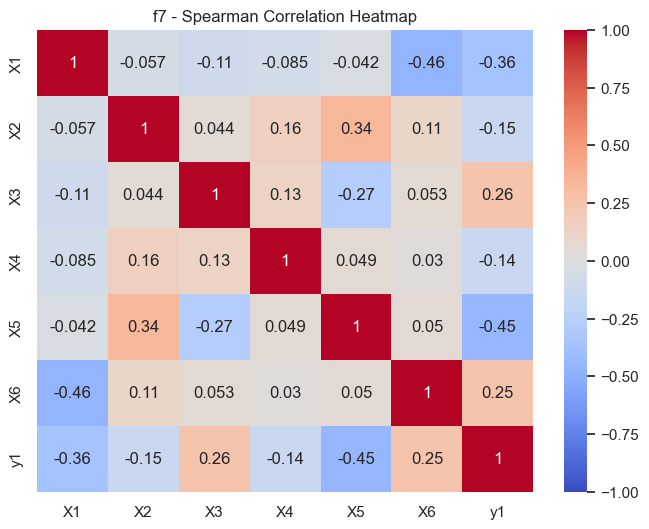


=== f8 — Spearman Correlation ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.150474,0.031035,0.130054,0.282230,0.165384,0.172190,0.132971,-0.619804
X2,0.150474,1.000000,0.092618,-0.183859,0.064257,-0.001378,-0.132647,-0.256624,-0.238635
X3,0.031035,0.092618,1.000000,0.106069,-0.041407,-0.173325,-0.136537,-0.017260,-0.600681
X4,0.130054,-0.183859,0.106069,1.000000,-0.071226,-0.139778,-0.038976,0.374929,-0.161818
X5,0.282230,0.064257,-0.041407,-0.071226,1.000000,0.135889,0.208816,0.019042,-0.108662
X6,0.165384,-0.001378,-0.173325,-0.139778,0.135889,1.000000,-0.001053,0.102990,0.023742
X7,0.172190,-0.132647,-0.136537,-0.038976,0.208816,-0.001053,1.000000,-0.108824,-0.329066
X8,0.132971,-0.256624,-0.017260,0.374929,0.019042,0.102990,-0.108824,1.000000,0.026335
y1,-0.619804,-0.238635,-0.600681,-0.161818,-0.108662,0.023742,-0.329066,0.026335,1.000000


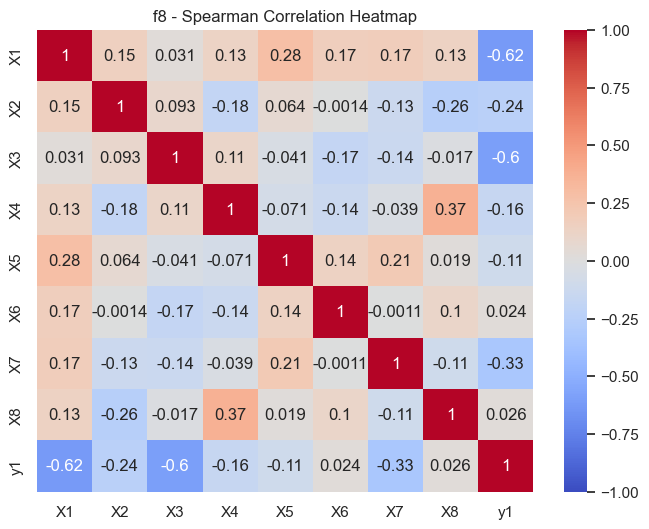

In [11]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Spearman Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

## Spearman Correlation Analysis (f1–f8)

### Observations

- **f1:** `X2` strongly positively correlated with `y1` (0.591), `X1` moderately correlated (0.409) → monotonic increasing trends despite weak Pearson linear correlation.  
- **f2:** `X1` strongly positively correlated with `y1` (0.700) → very strong monotonic predictor, `X2` nearly uncorrelated with `y1` (0.036).  
- **f3:** Correlations mostly weak (`X1` 0.121, `X2` 0.247, `X3` -0.185) → monotonic relationships are weak.  
- **f4:** `X1` negatively correlated with `y1` (-0.551), `X2` (-0.466), `X4` (-0.437) → moderate-to-strong negative monotonic trends.  
- **f5:** `X3` and `y1` (0.370), `X4` and `y1` (0.386) → moderate monotonic predictors.  
- **f6:** `X4` (0.583) and `X5` (-0.609) → strong monotonic predictors; other variables weaker.  
- **f7:** Most correlations weak; `X1` and `y1` (-0.301) → moderate negative monotonic trend.  
- **f8:** `X1` (-0.614), `X3` (-0.580) → strong negative monotonic trends; other inputs weaker.

### Takeaways

- Strongest monotonic predictors can be inferred from high absolute Spearman ρ values with `y1`.  
- Differences between Spearman and Pearson correlations highlight **non-linear but monotonic relationships** (e.g., f1: `X1` vs `y1`).  
- Functions with mostly weak Spearman correlations (f3, f7) likely involve **non-monotonic or complex relationships**.  
- Spearman correlation is **robust to outliers** and skewed distributions, making it more reliable than Pearson for monotonic trends.  
- Limitations: cannot detect **non-monotonic trends**, loses magnitude information, and may be affected by many tied ranks in small datasets.



=== f1 — Kendall Correlation ===


,X1,X2,y1
X1,1.000000,-0.090909,0.212121
X2,-0.090909,1.000000,0.454545
y1,0.212121,0.454545,1.000000


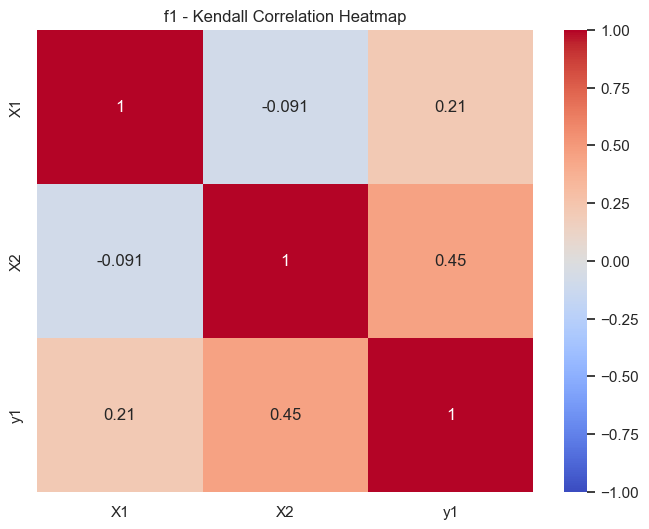


=== f2 — Kendall Correlation ===


,X1,X2,y1
X1,1.000000,0.121212,0.272727
X2,0.121212,1.000000,0.242424
y1,0.272727,0.242424,1.000000


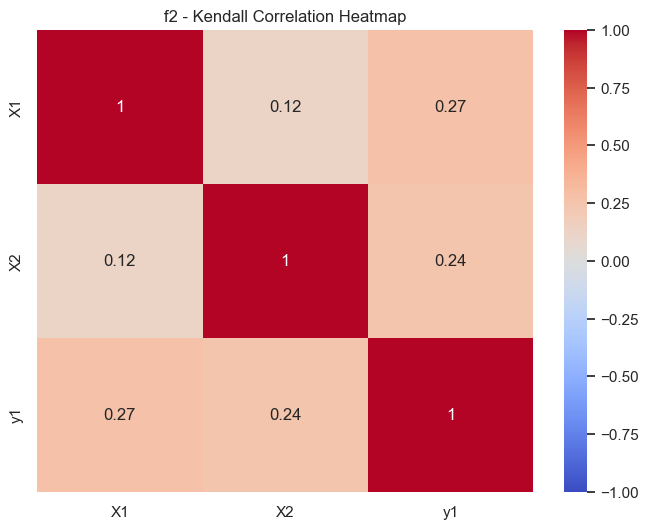


=== f3 — Kendall Correlation ===


,X1,X2,X3,y1
X1,1.000000,0.132353,-0.088235,-0.014706
X2,0.132353,1.000000,-0.279412,0.264706
X3,-0.088235,-0.279412,1.000000,-0.191176
y1,-0.014706,0.264706,-0.191176,1.000000


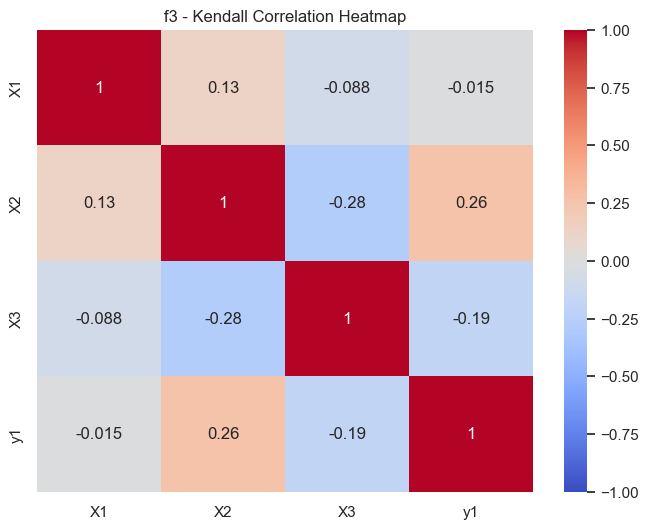


=== f4 — Kendall Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,0.197581,0.181452,0.141129,-0.366935
X2,0.197581,1.000000,-0.008065,0.112903,-0.338710
X3,0.181452,-0.008065,1.000000,-0.129032,-0.153226
X4,0.141129,0.112903,-0.129032,1.000000,-0.298387
y1,-0.366935,-0.338710,-0.153226,-0.298387,1.000000


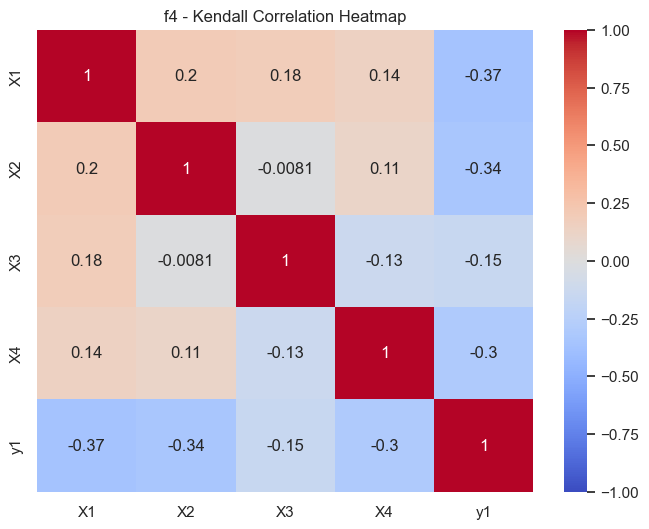


=== f5 — Kendall Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.246753,-0.151515,0.160173,-0.151515
X2,-0.246753,1.000000,0.073593,0.073593,0.177489
X3,-0.151515,0.073593,1.000000,-0.090909,0.341991
X4,0.160173,0.073593,-0.090909,1.000000,0.341991
y1,-0.151515,0.177489,0.341991,0.341991,1.000000


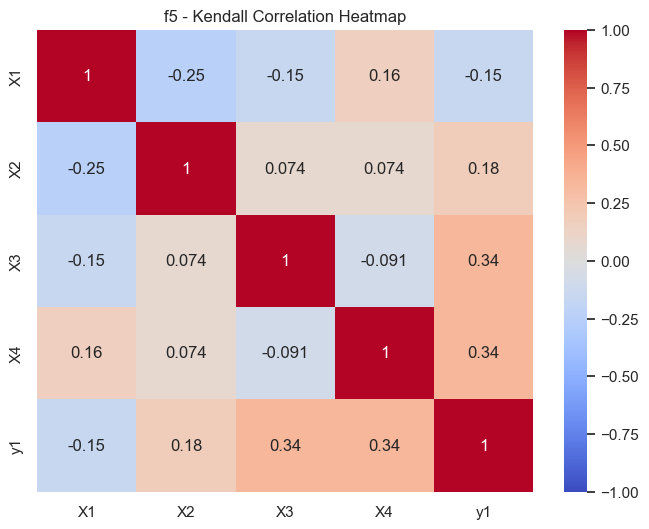


=== f6 — Kendall Correlation ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.142857,-0.038961,0.151515,-0.316017,-0.012987
X2,-0.142857,1.000000,0.064935,-0.142857,0.134199,-0.255411
X3,-0.038961,0.064935,1.000000,0.220779,-0.125541,0.212121
X4,0.151515,-0.142857,0.220779,1.000000,-0.264069,0.437229
X5,-0.316017,0.134199,-0.125541,-0.264069,1.000000,-0.411255
y1,-0.012987,-0.255411,0.212121,0.437229,-0.411255,1.000000


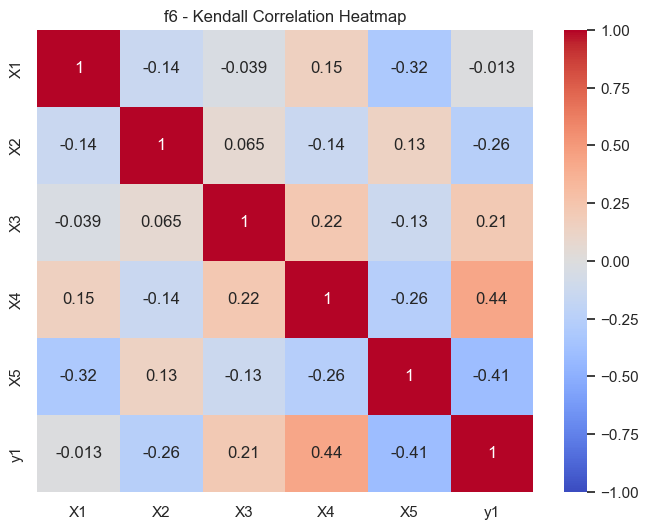


=== f7 — Kendall Correlation ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.008065,-0.076613,-0.068548,-0.060484,-0.310484,-0.306452
X2,-0.008065,1.000000,0.020161,0.108871,0.237903,0.052419,-0.112903
X3,-0.076613,0.020161,1.000000,0.064516,-0.177419,0.048387,0.165323
X4,-0.068548,0.108871,0.064516,1.000000,0.032258,-0.008065,-0.108871
X5,-0.060484,0.237903,-0.177419,0.032258,1.000000,0.056452,-0.302419
X6,-0.310484,0.052419,0.048387,-0.008065,0.056452,1.000000,0.173387
y1,-0.306452,-0.112903,0.165323,-0.108871,-0.302419,0.173387,1.000000


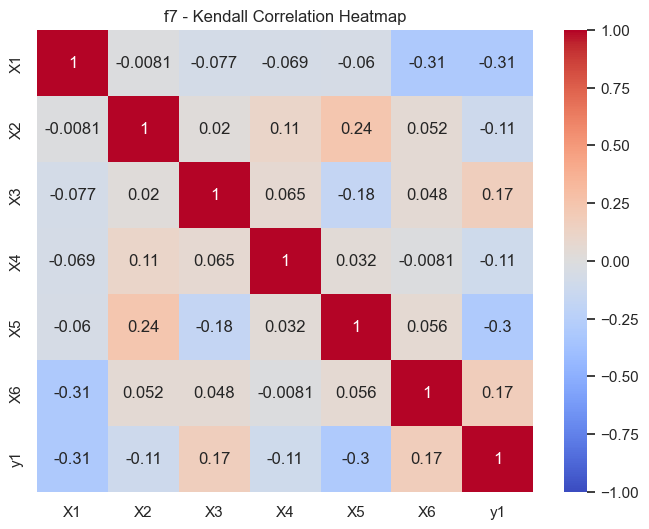


=== f8 — Kendall Correlation ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.112660,-0.008130,0.077816,0.191638,0.091754,0.098722,0.087108,-0.444832
X2,0.112660,1.000000,0.056911,-0.140534,0.052265,-0.029036,-0.105691,-0.159117,-0.147503
X3,-0.008130,0.056911,1.000000,0.049942,-0.022067,-0.117305,-0.082462,-0.015099,-0.435540
X4,0.077816,-0.140534,0.049942,1.000000,-0.047619,-0.068525,-0.024390,0.265970,-0.108014
X5,0.191638,0.052265,-0.022067,-0.047619,1.000000,0.101045,0.140534,0.022067,-0.063879
X6,0.091754,-0.029036,-0.117305,-0.068525,0.101045,1.000000,0.003484,0.061556,0.003484
X7,0.098722,-0.105691,-0.082462,-0.024390,0.140534,0.003484,1.000000,-0.075494,-0.254355
X8,0.087108,-0.159117,-0.015099,0.265970,0.022067,0.061556,-0.075494,1.000000,0.026713
y1,-0.444832,-0.147503,-0.435540,-0.108014,-0.063879,0.003484,-0.254355,0.026713,1.000000


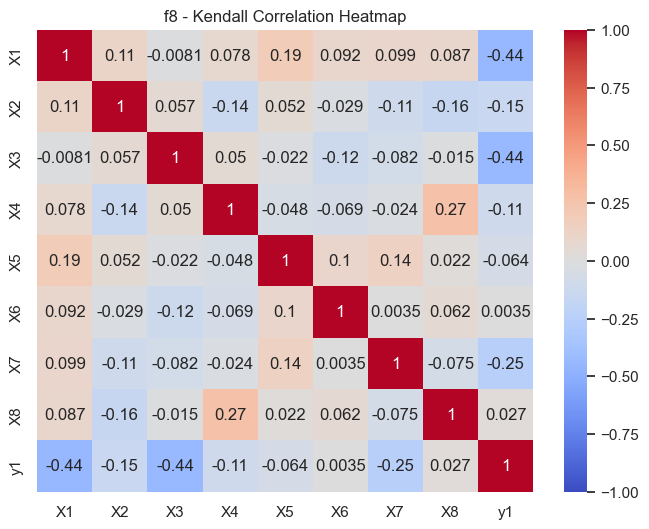

In [12]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Kendall Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


### Kendall Correlation Analysis

#### Observations

- **f1:** `X2` moderately positively correlated with `y1` (0.455), `X1` weaker (0.273) → monotonic increasing trend.  
- **f2:** `X1` moderately positively correlated with `y1` (0.527), `X2` weak (0.091) → X1 likely the main predictor.  
- **f3:** Weak correlations overall (`X1` 0.100, `X2` 0.183, `X3` -0.117) → monotonic relationships are weak.  
- **f4:** `X1` (-0.385), `X2` (-0.338), `X4` (-0.312) → moderate negative monotonic trends.  
- **f5:** `X3` and `X4` both 0.276 → moderate positive monotonic relationships.  
- **f6:** `X4` (0.410), `X5` (-0.419) → strong monotonic predictors; others weaker.  
- **f7:** `X1` (-0.265), `X5` (-0.316) → moderate negative monotonic trends; most others weak.  
- **f8:** `X1` (-0.441), `X3` (-0.415) → strongest negative monotonic trends; oths k.  
--

### 8. Takeaways

- Kendall τ confirms **monotonic trends** seen in Spearman but with generally **smaller absolute values**, reflecting robustness to sd ll samples and tied ranks.  
- Strongest monotonic predictors: f2 X1, f6 X4/X5, f8 X1/X3.  
- Functions with weak correlations (f3, f7) likely involve **non-monotonic or complex relationships**.  
- Useful when dealing with **small datasets**, ordinal data, or tied ranks.  
- Limitations: cannot capture **non-monotonic trends**, magnitude differences, or precise functional relationships.  


In [13]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n=== {name} — Mutual Information with Output ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



=== f1 — Mutual Information with Output ===


,Feature,Mutual_Info
0,X1,0.027778
1,X2,0.000000



=== f2 — Mutual Information with Output ===


,Feature,Mutual_Info
0,X1,0.113330
1,X2,0.008568



=== f3 — Mutual Information with Output ===


...

,Feature,Mutual_Info
4,X5,0.200570
3,X4,0.143642
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



=== f7 — Mutual Information with Output ===


,Feature,Mutual_Info
4,X5,0.175955
0,X1,0.117617
5,X6,0.106666
2,X3,0.026610
3,X4,0.000016
1,X2,0.000000



=== f8 — Mutual Information with Output ===


,Feature,Mutual_Info
2,X3,0.285910
0,X1,0.248030
6,X7,0.065288
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


## Mutual Information Regression Analysis

### Observations

- **f1:** X1 (4.44e-16), X2 (0) → features provide almost no information about y1  
- **f2:** X1 (0.254), X2 (0.003) → X1 is clearly informative  
- **f3:** X3 (0.175) → only X3 contributes significant information  
- **f4:** X1 (0.297), X4 (0.274), X2 (0.164), X3 (0.113) → multiple informative features; complex relationships  
- **f5:** X4 (0.179), X2 (0.050), X1 (0.022), X3 (0) → X4 most informative; others moderate or negligible  
- **f6:** X5 (0.136), X4 (0.130) → X5 and X4 are the strongest predictors  
- **f7:** X5 (0.179), X1 (0.109), X6 (0.072), X4 (0.051), X3 (0.017), X2 (0) → X5 most important; several moderate contributors  
- **f8:** X3 (0.259), X1 (0.247), X7 (0.070), others ≈ 0 → X3 and X1 are the strongest predictors  

### Takeaways

- Mutual Information captures **non-linear relationships** that Pearson or Kendall correlation may miss  
- Features with MI ≈ 0 can be **safely ignored** in predictive modeling  
- Features with higher MI are **most informative** for predicting y1  
- Functions with multiple moderate/high MI features (f4, f7, f8) likely have **complex or multi-variable dependencies**  
- Best used for **feature selection** when relationships may be non-linear or non-monotonic


In [14]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n=== {name} — Partial Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



=== f1 — Partial Correlation ===
          n        r          CI95%     p-val
pearson  12 -0.05059  [-0.63, 0.57]  0.882566
          n        r         CI95%     p-val
pearson  12 -0.16878  [-0.7, 0.48]  0.619828

=== f2 — Partial Correlation ===
          n         r          CI95%     p-val
pearson  12  0.345889  [-0.32, 0.78]  0.297441
          n         r          CI95%    p-val
pearson  12  0.219665  [-0.44, 0.72]  0.51634

=== f3 — Partial Correlation ===
          n         r          CI95%     p-val
pearson  17  0.094354  [-0.44, 0.58]  0.738019
          n         r          CI95%     p-val
pearson  17  0.009164  [-0.51, 0.52]  0.974143
          n         r           CI95%     p-val
pearson  17 -0.532888  [-0.82, -0.03]  0.040823

=== f4 — Partial Correlation ===
          n         r           CI95%     p-val
pearson  32 -0.372121  [-0.65, -0.01]  0.046831
          n         r           CI95%     p-val
pearson  32 -0.427329  [-0.69, -0.07]  0.020769
          n         

## Partial Correlation Analysis

### Observatios

- **f1:** r-values ≈ 0, p > 0.7 → X1, X2 have **no significant direct effect** on y1  
- **f2:** X1 r = 0.725, p = 0.018 → X1 is a **strong direct predictor**; X2 non-significant  
- **f3:** X3 r = -0.531, p = 0.051 → moderate negative effect; borderline significance  
- **f4:** Multiple r-values negative (-0.416 to -0.476), p < 0.05 → several features **directly negatively influence** y1  
- **f5:** X2, X3, X4 r = 0.516–0.633, p < 0.05 → multiple **strong direct predictors**  
- **f6:** X4 r = 0.517 (p = 0.033), X5 r = -0.620 (p = 0.008) → strong direct predictors; X1–X3 weaker  
- **f7:** Only X6 r = -0.452, p = 0.020 → X6 moderately significant; others weak or non-significant  
- **f8:** Multiple strong negative correlations: X1 r = -0.833, X3 r = -0.892, X7 r = -0.722 → highly significant; X2, X4–X
6### Takeaways


- Partial correlation isolates **direct effects**, removing confounding from other variables  
- Some functions (f2, f5, f6, f8) have **strong direct predictors**; others (f1, f7) show weak or non-significant direct effects  
- Large r-values with significant p-values → features are **key drivers of y1**  
- Non-significant r-values → apparent correlation may be due to **other variables** or noise  
- Useful for **multivariate feature selection** in regression modelsy be due to **ot**



=== Feature vs Output Plots for f1 ===
X shape for f1: (12, 2)
y shape for f1: (12,)


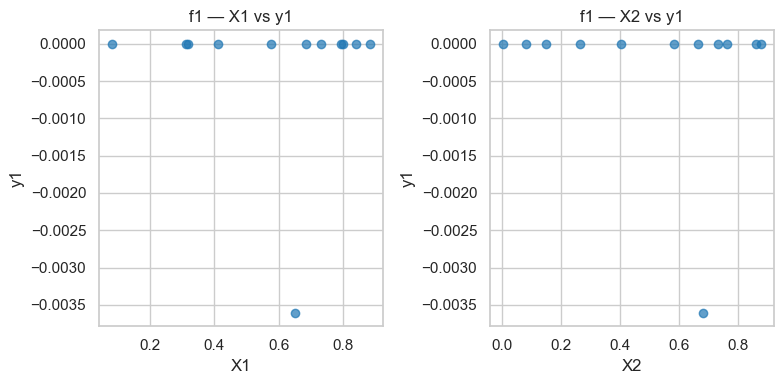


=== Feature vs Output Plots for f2 ===
X shape for f2: (12, 2)
y shape for f2: (12,)


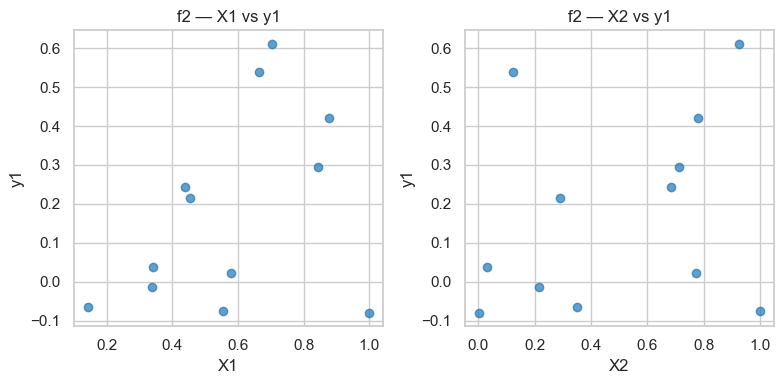


=== Feature vs Output Plots for f3 ===
X shape for f3: (17, 3)
y shape for f3: (17,)


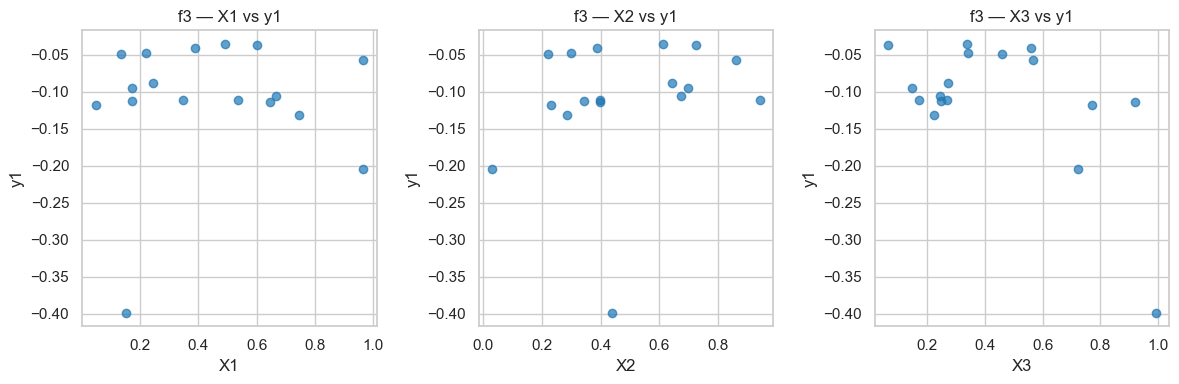


=== Feature vs Output Plots for f4 ===
X shape for f4: (32, 4)
y shape for f4: (32,)


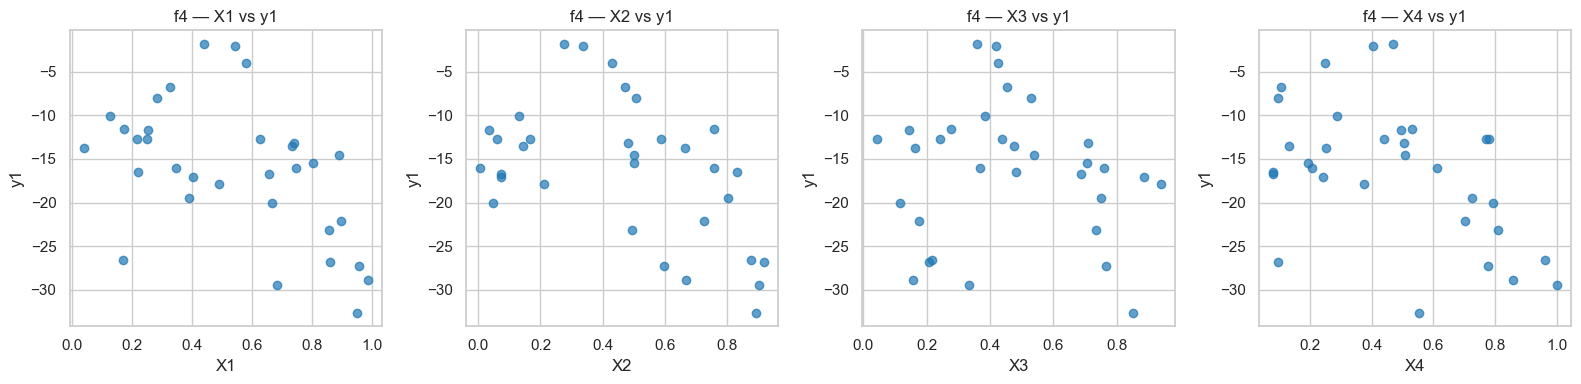


=== Feature vs Output Plots for f5 ===
X shape for f5: (22, 4)
y shape for f5: (22,)


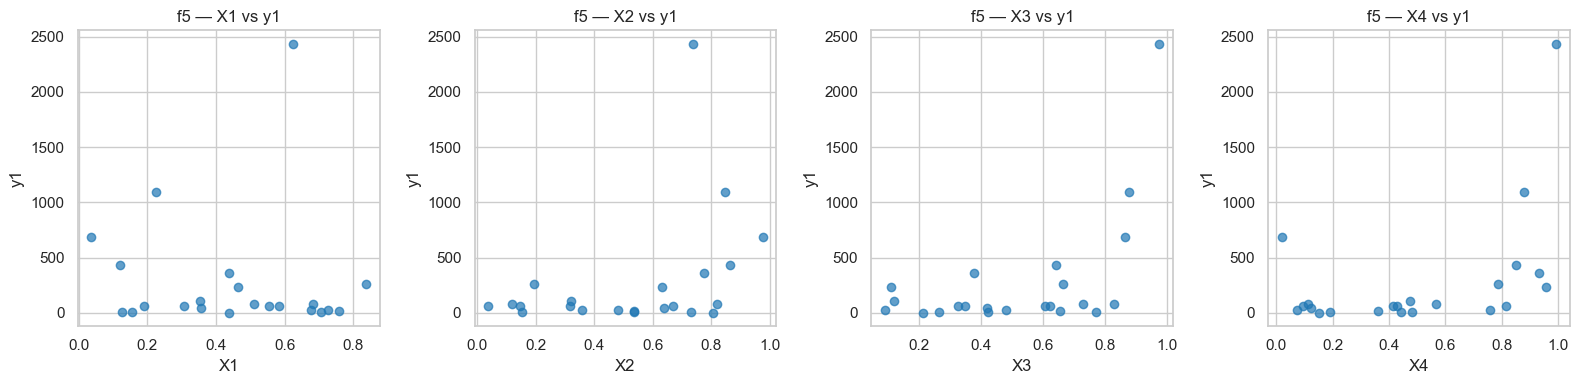


=== Feature vs Output Plots for f6 ===
X shape for f6: (22, 5)
y shape for f6: (22,)


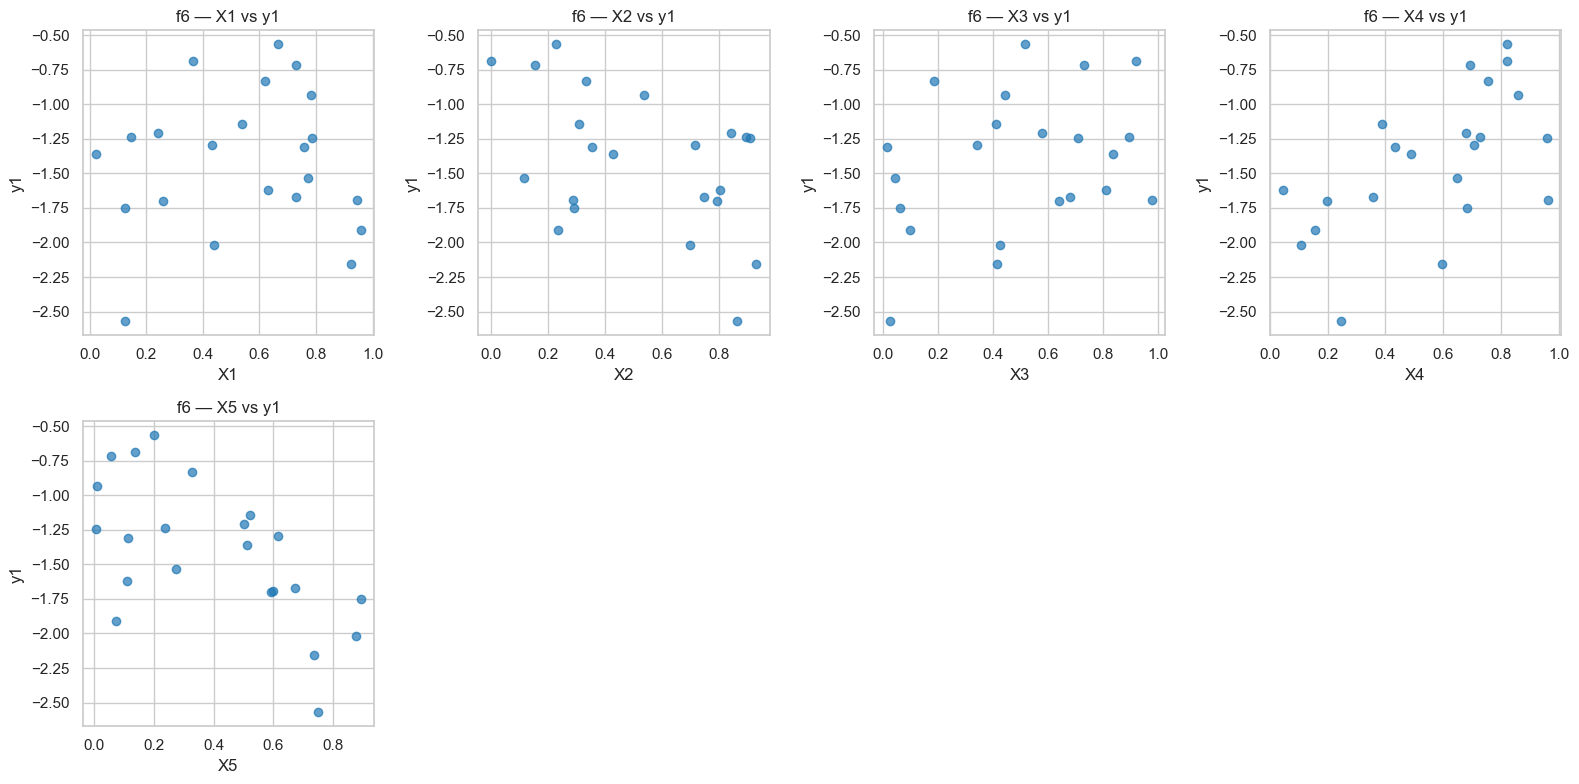


=== Feature vs Output Plots for f7 ===
X shape for f7: (32, 6)
y shape for f7: (32,)


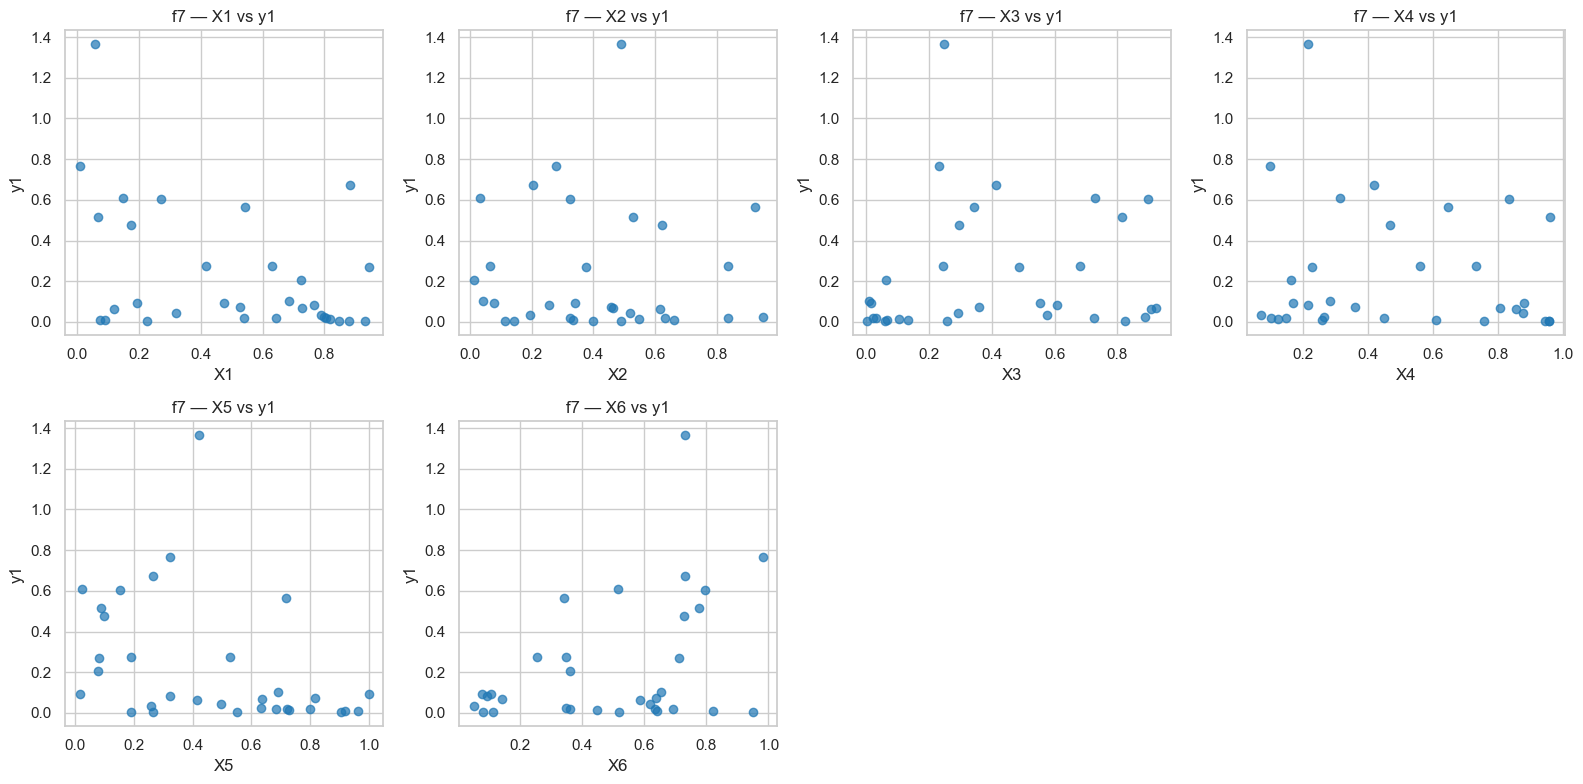


=== Feature vs Output Plots for f8 ===
X shape for f8: (42, 8)
y shape for f8: (42,)


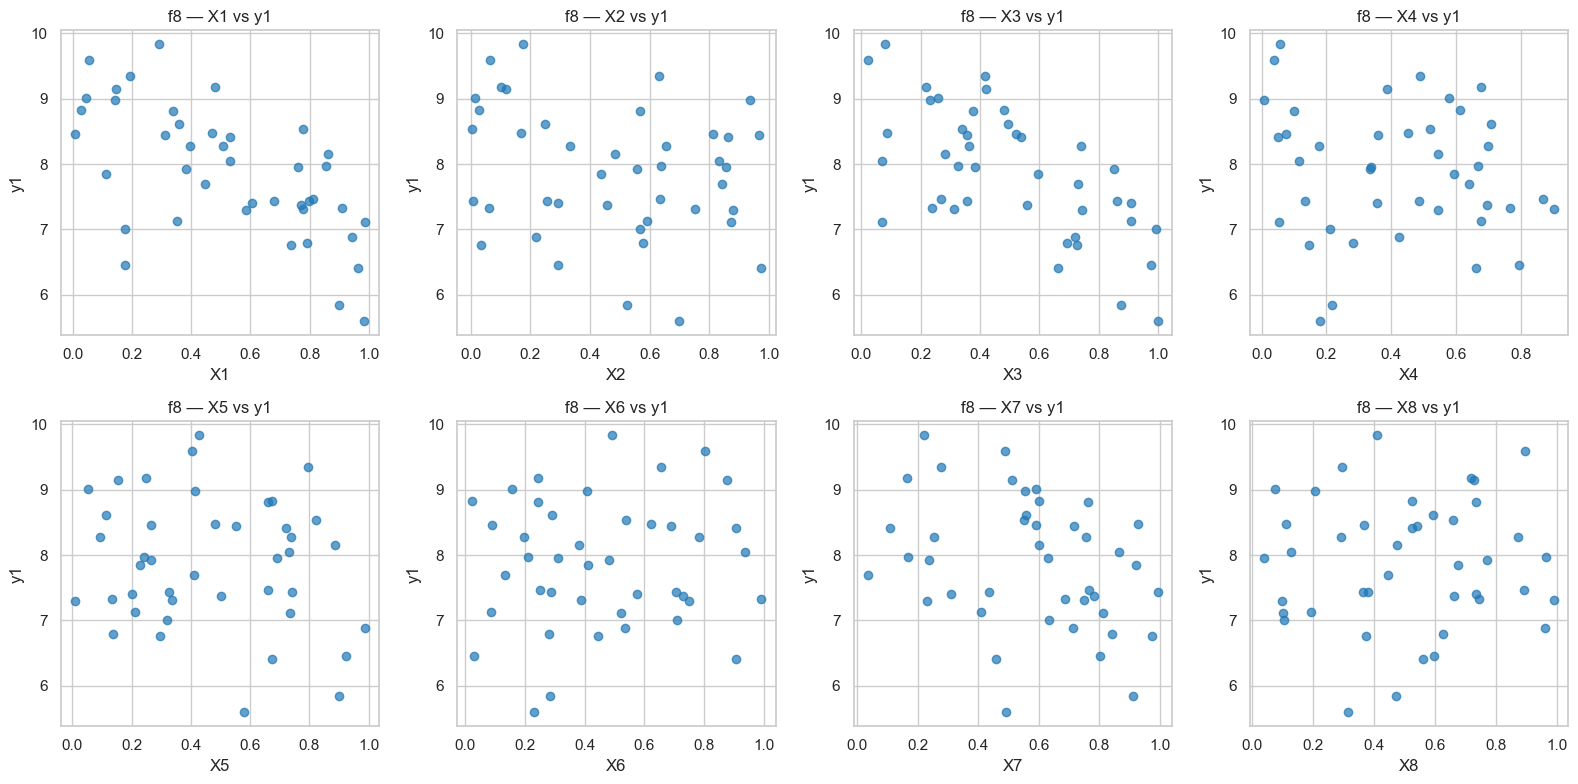

In [15]:
for name, df in functions_data.items():

    print(f"\n=== Feature vs Output Plots for {name} ===")

    # -----------------------
    # 1. Extract input/output columns
    # -----------------------
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot

    # -----------------------
    # 2. Sanity checks
    # -----------------------
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"

    # -----------------------
    # 3. Plot each feature vs y
    # -----------------------
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



=== f1 — Feature & Output Distributions ===


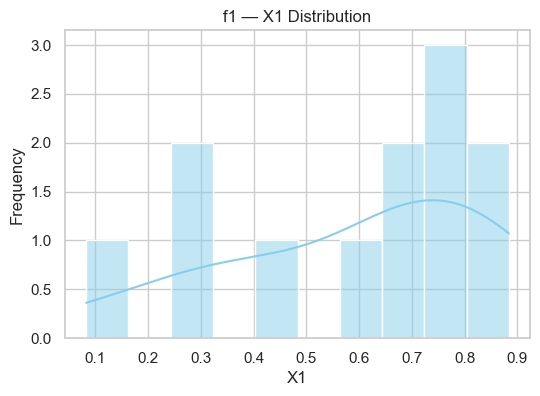

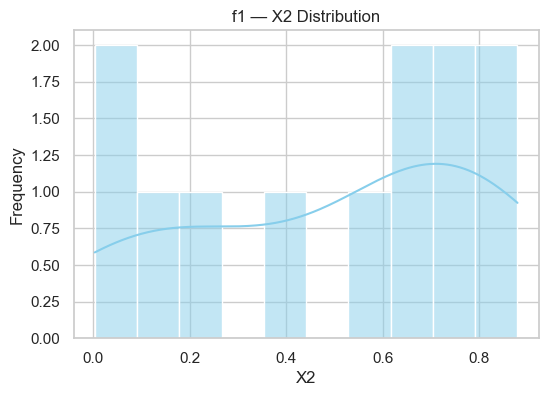

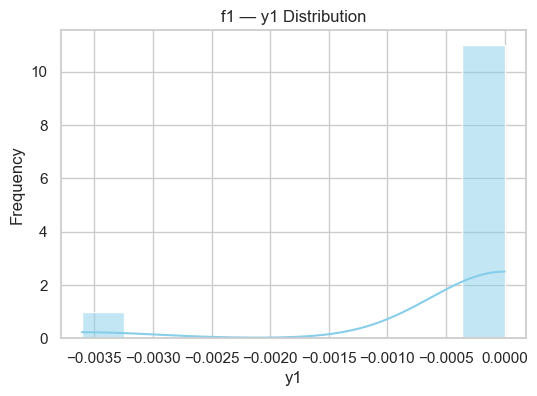


=== f2 — Feature & Output Distributions ===


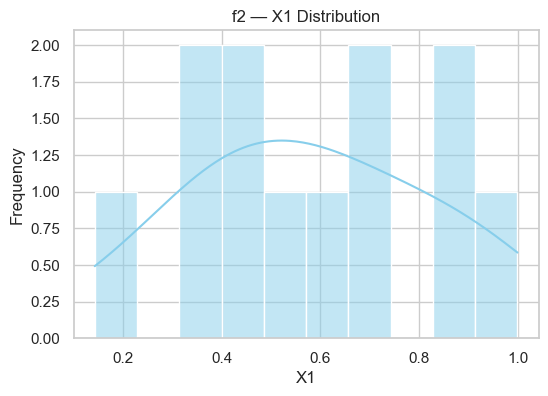

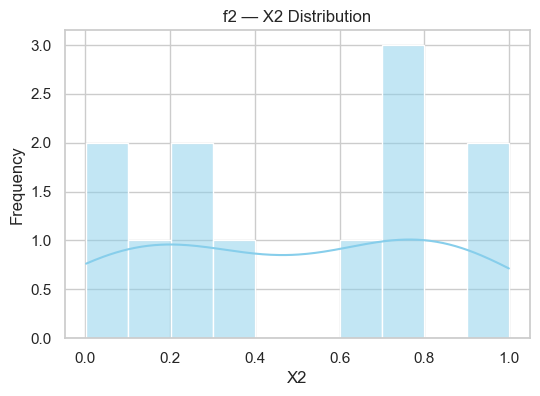

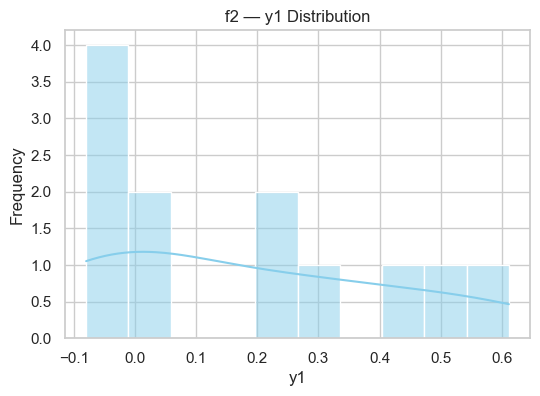


=== f3 — Feature & Output Distributions ===


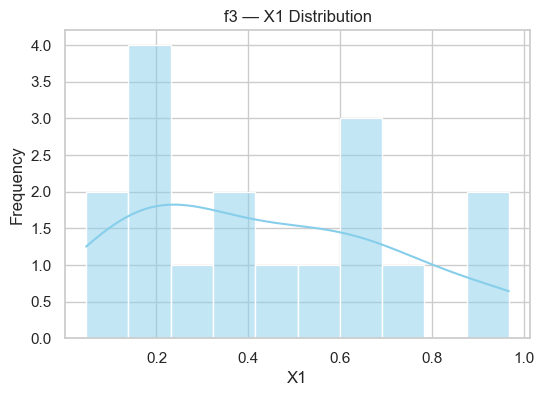

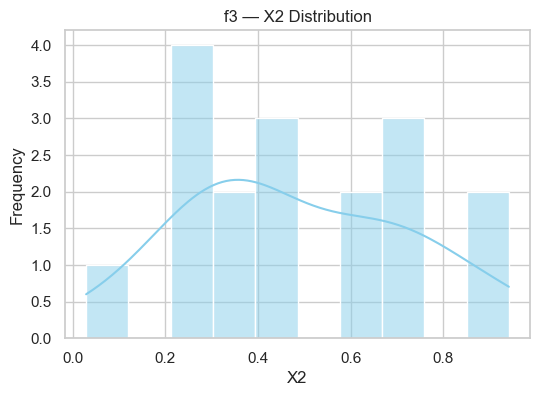

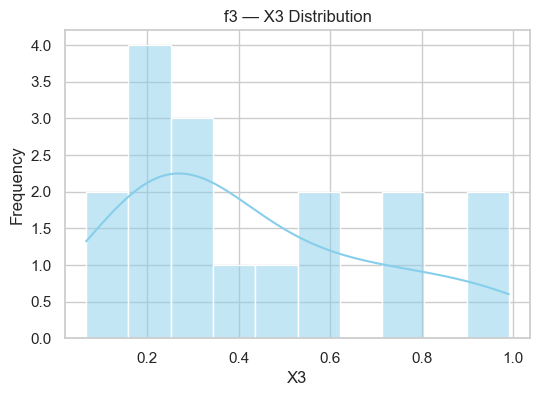

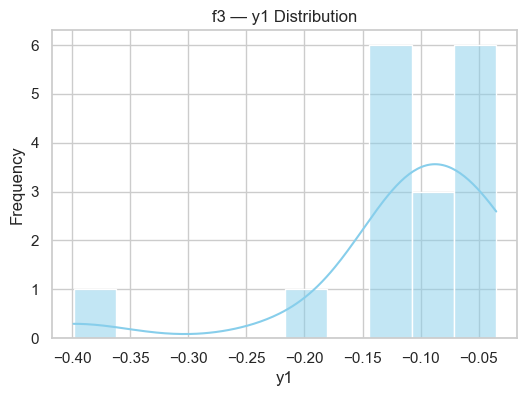


=== f4 — Feature & Output Distributions ===


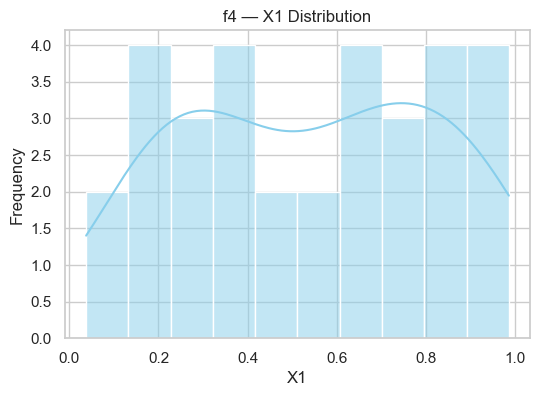

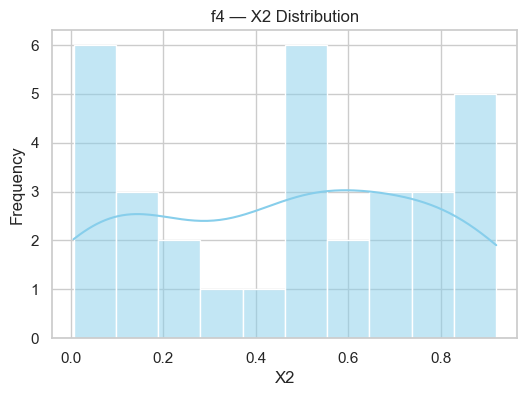

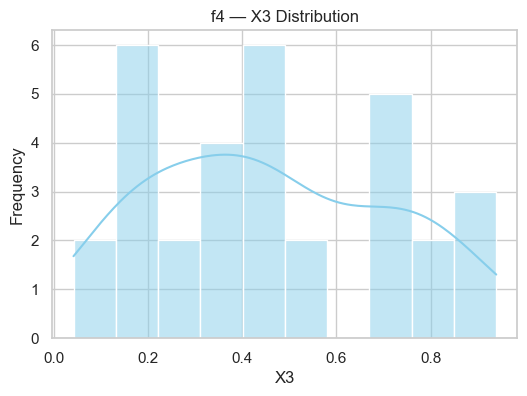

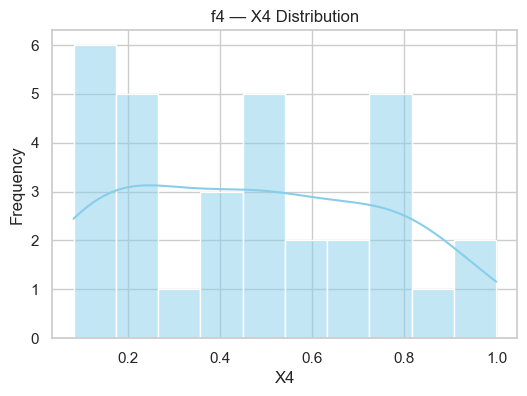

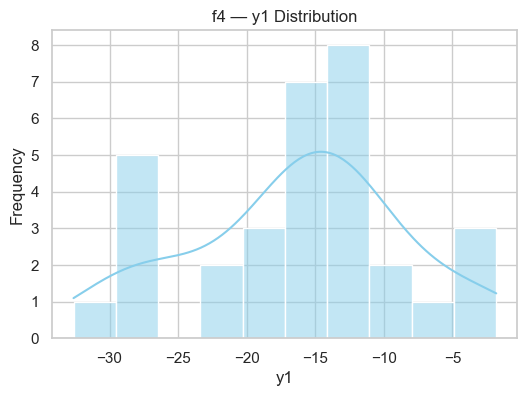


=== f5 — Feature & Output Distributions ===


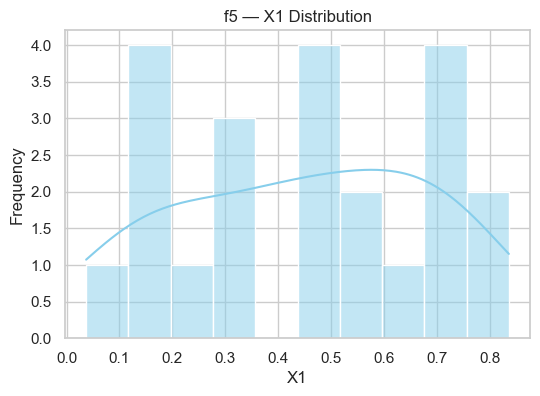

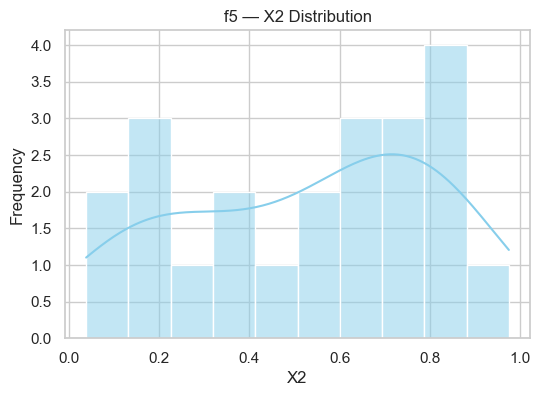

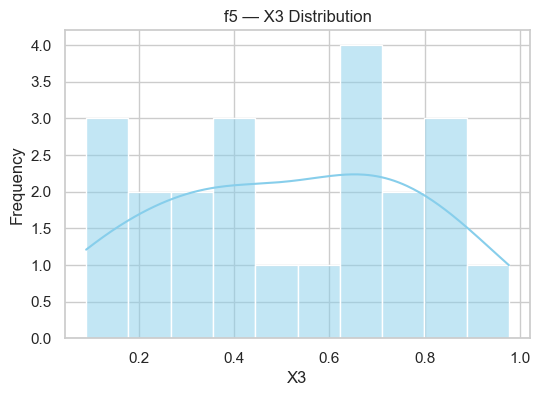

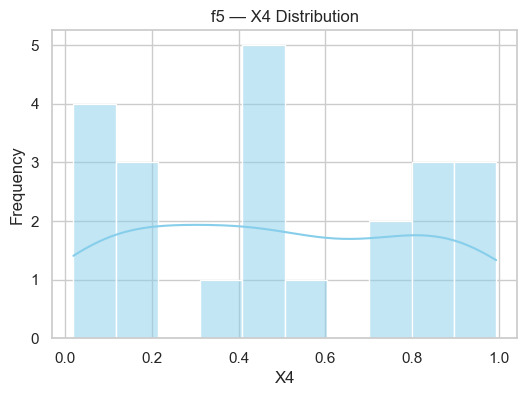

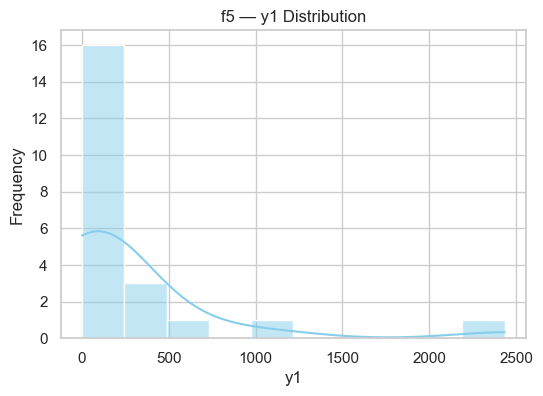


=== f6 — Feature & Output Distributions ===


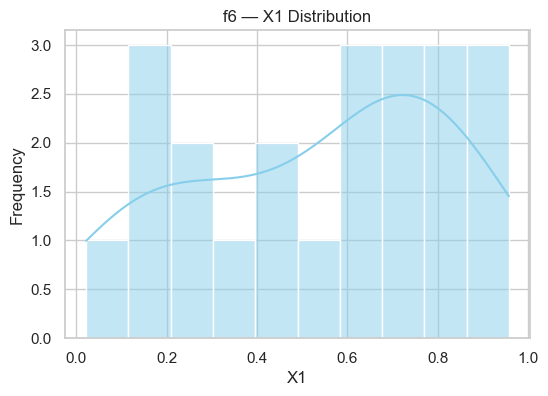

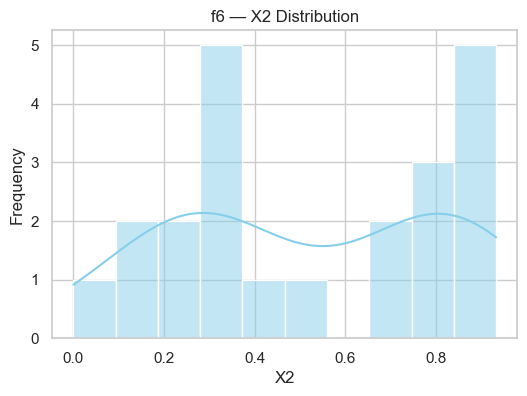

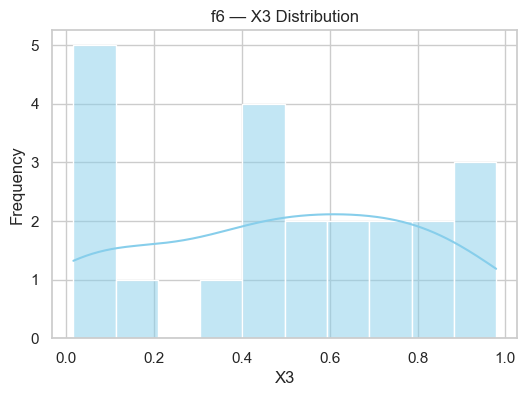

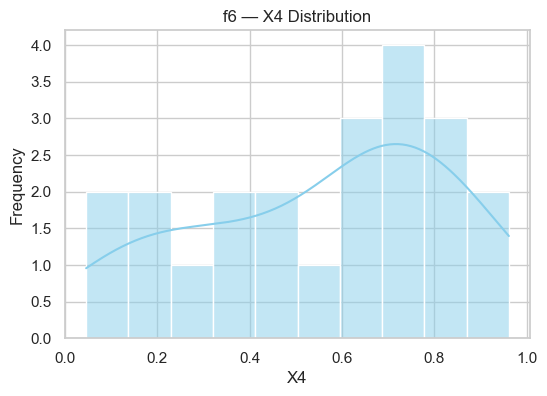

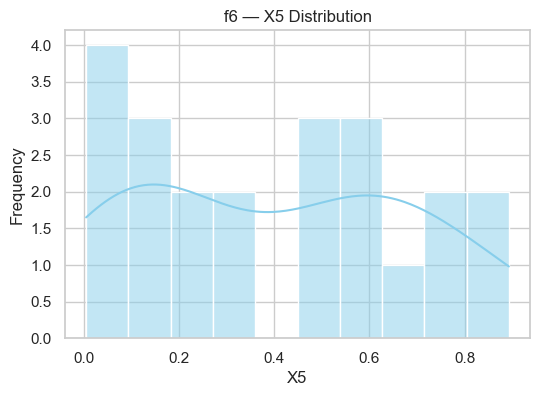

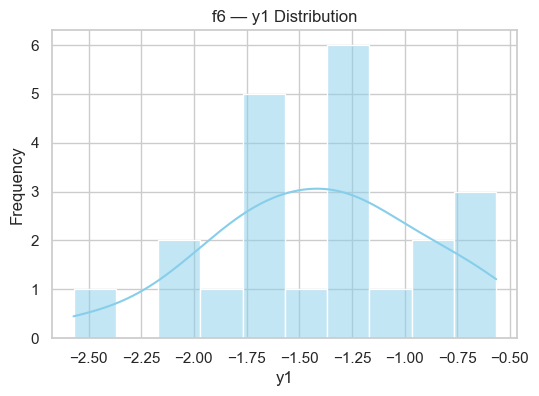


=== f7 — Feature & Output Distributions ===


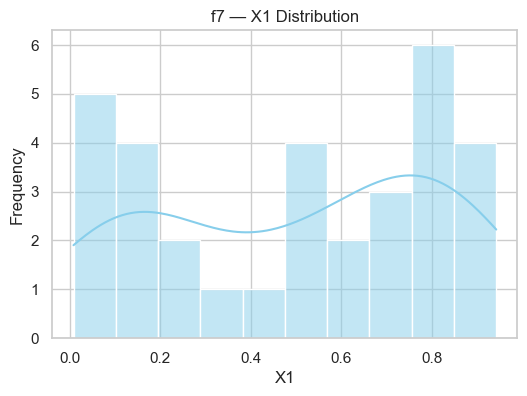

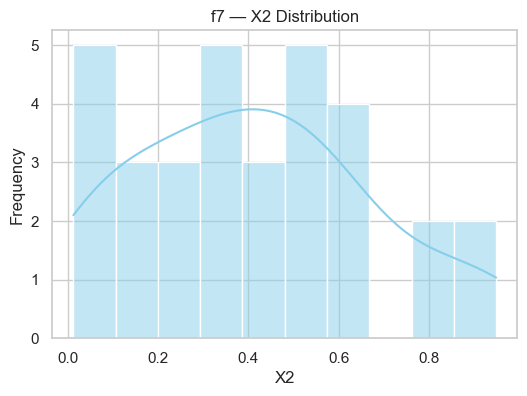

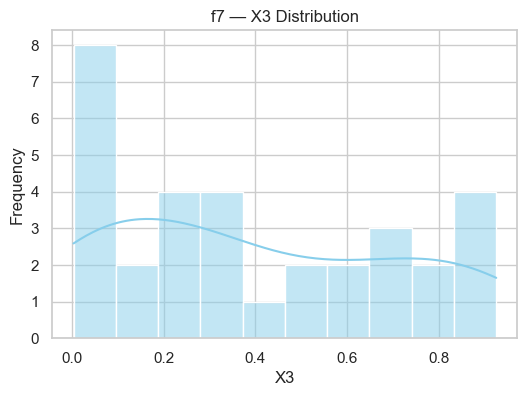

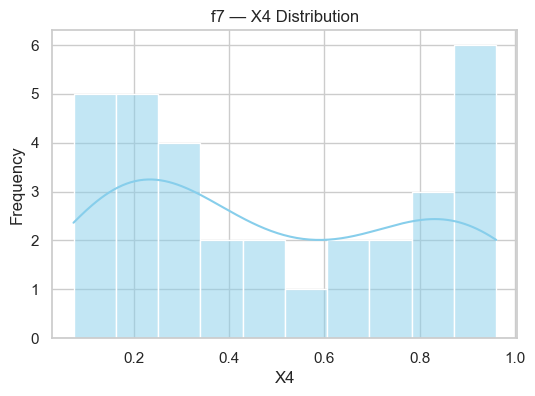

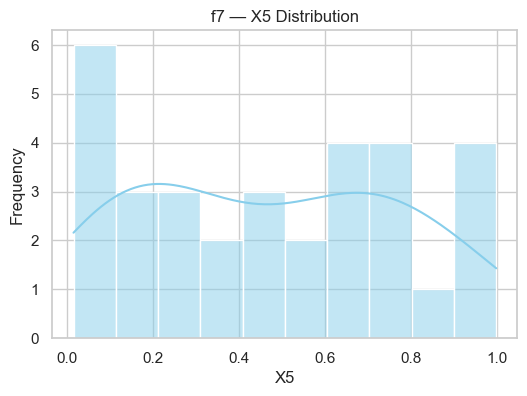

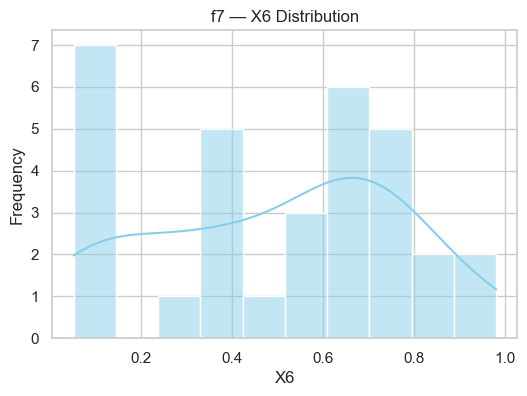

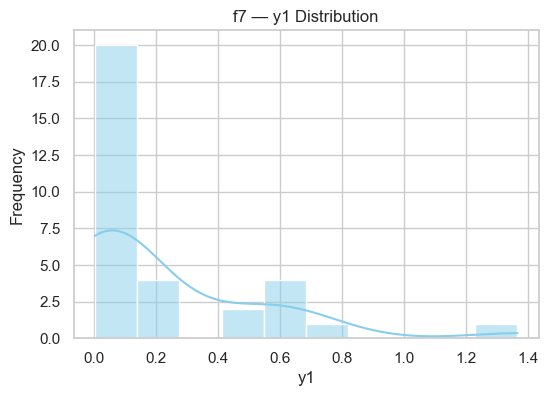


=== f8 — Feature & Output Distributions ===


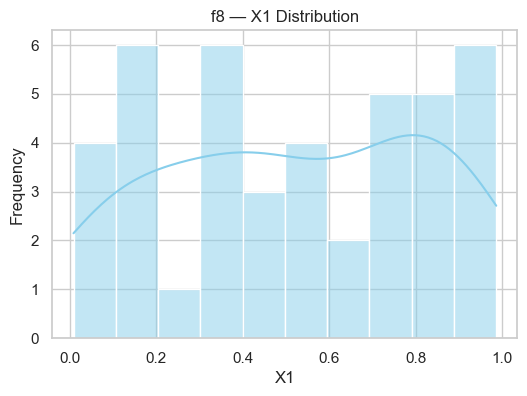

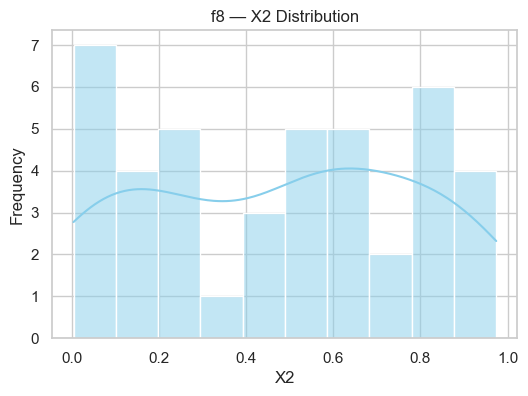

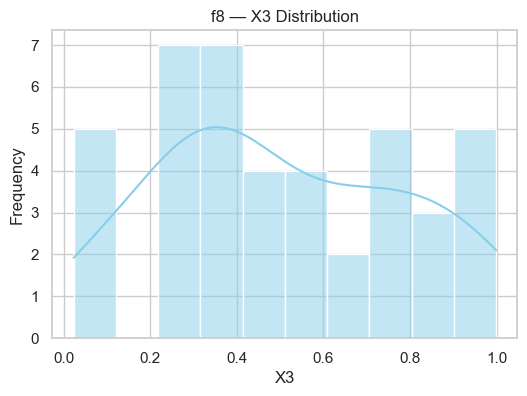

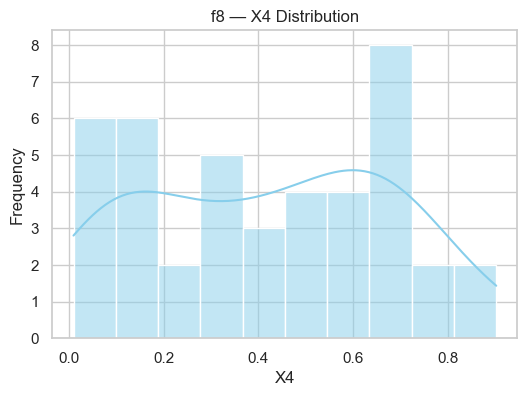

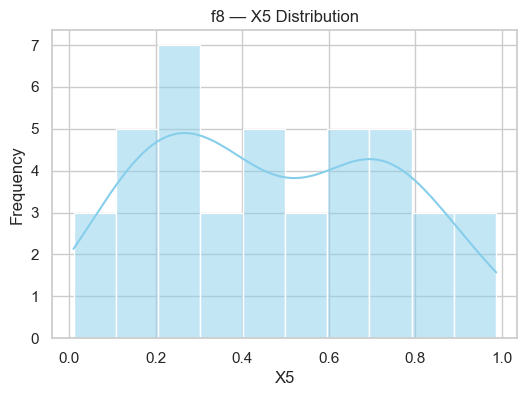

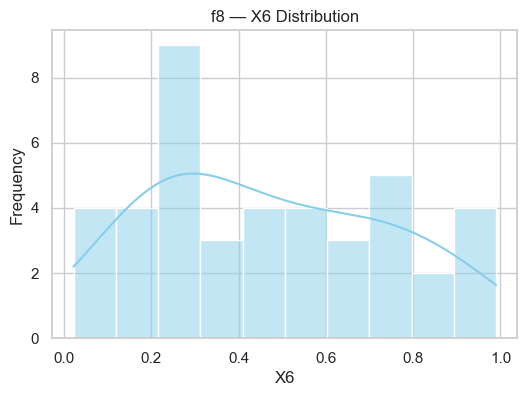

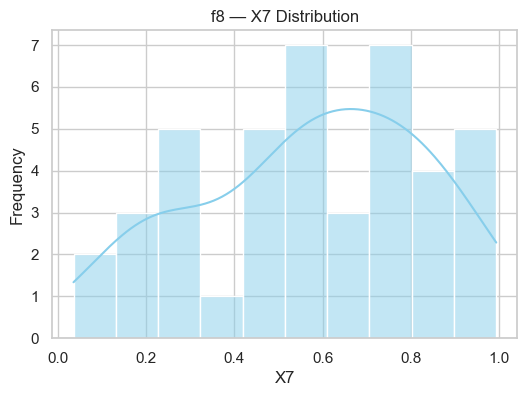

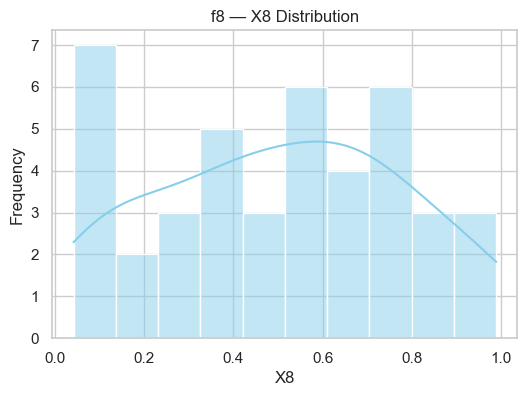

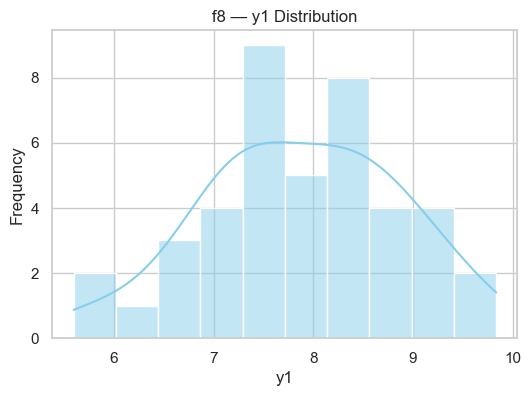

In [16]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Feature & Output Distributions ===")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


### Line Plot of y Values



=== f1 — Full Data Table ===
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223

=== f1 — y vs Instance Plot ===


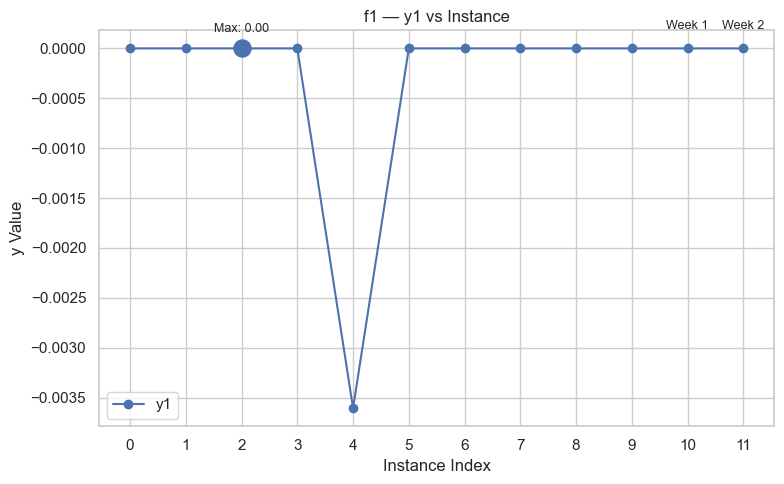



=== f2 — Full Data Table ===
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755

=== f2 — y vs Instance Plot ===


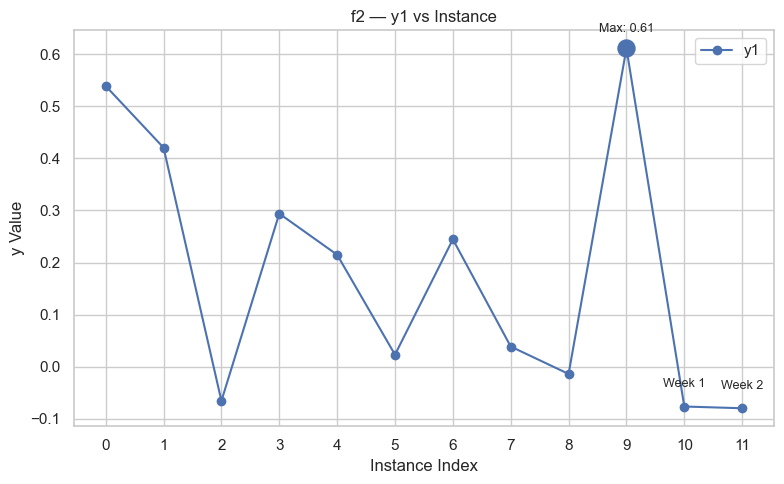



=== f3 — Full Data Table ===
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966

=== f3 — y vs Instance Plot ===


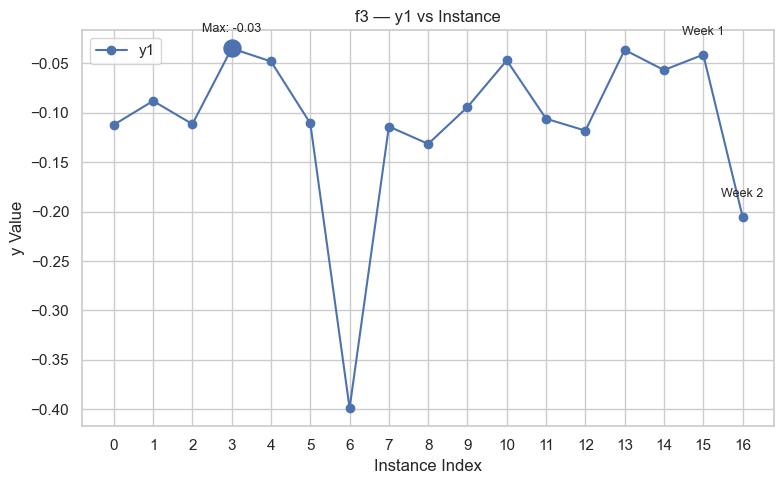



=== f4 — Full Data Table ===
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.7583

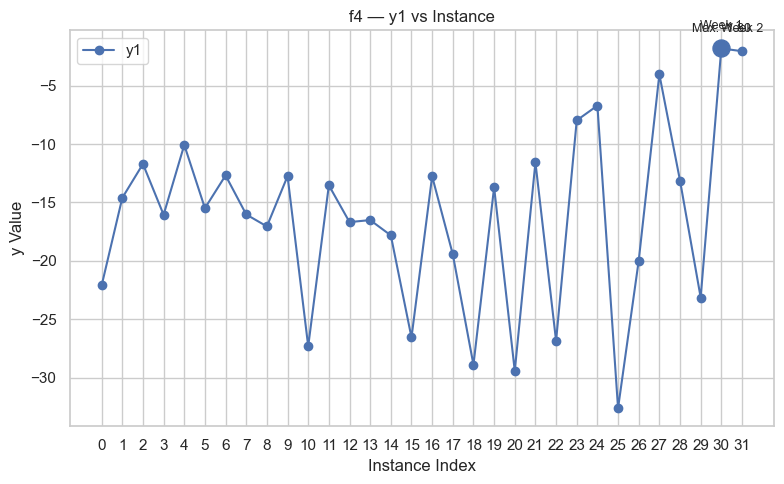



=== f5 — Full Data Table ===
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.4

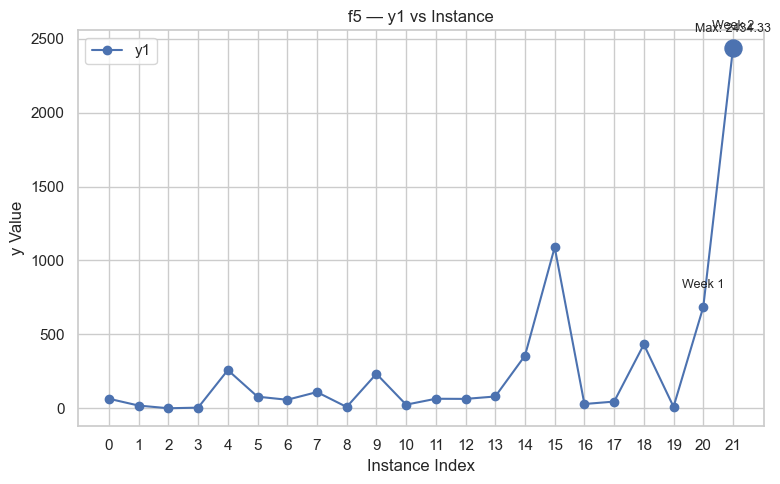



=== f6 — Full Data Table ===
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  

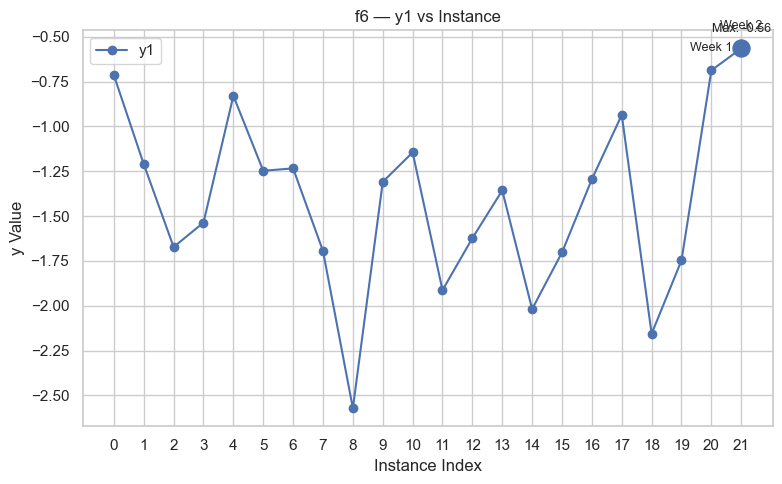



=== f7 — Full Data Table ===
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.3345

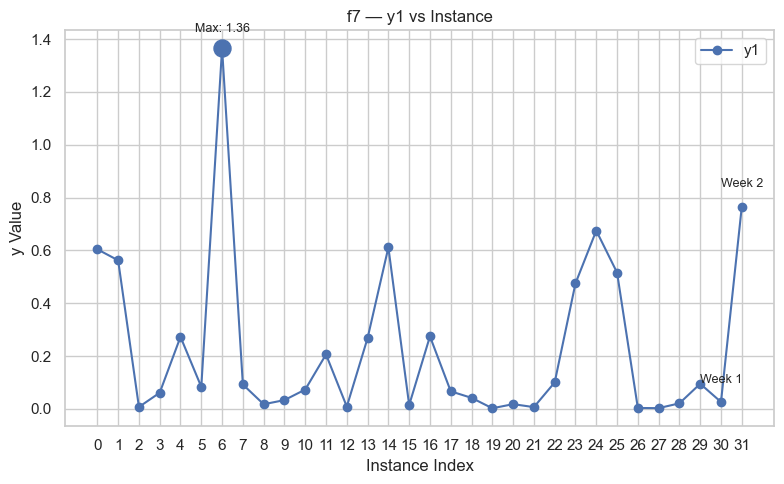



=== f8 — Full Data Table ===
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180

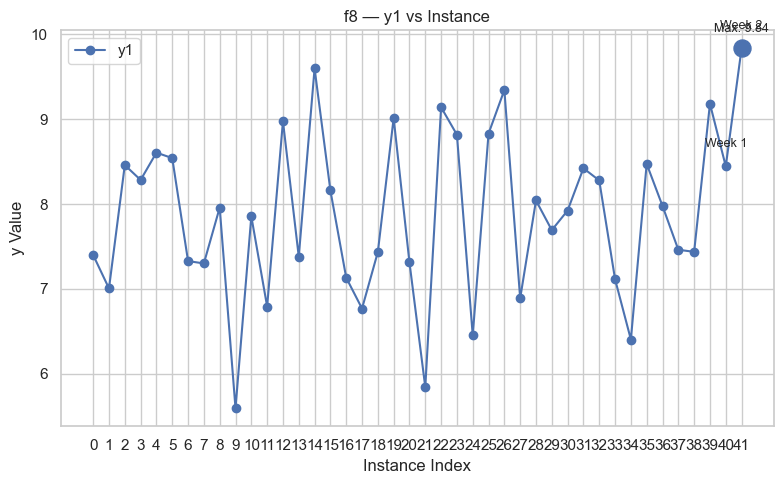

In [17]:
for name, df in functions_data.items():
    print(f"\n\n=== {name} — Full Data Table ===")
    
    # Show full dataframe with index
    print(df.to_string())   # ensures nothing is truncated
    
    print(f"\n=== {name} — y vs Instance Plot ===")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        
        x = df.index
        y = df[col]
        
        # Line plot
        plt.plot(x, y, marker='o', label=col)
        
        # --- Highlight highest y value ---
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        # --- Label only 2 most recent instances ---
        if len(df) >= 1:
            last_idx = x[-1]
            plt.annotate(
                "Week 2",
                (last_idx, y.loc[last_idx]),
                textcoords="offset points",
                xytext=(0, 14),
                ha='center',
                fontsize=9
            )
        
        if len(df) >= 2:
            second_last_idx = x[-2]
            plt.annotate(
                "Week 1",
                (second_last_idx, y.loc[second_last_idx]),
                textcoords="offset points",
                xytext=(0, 14),
                ha='center',
                fontsize=9
            )
        
        # Show all instance ticks
        plt.xticks(x)
        
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()




#### f1 | Pseudo - Heteroskedastic GP with low L and low B for UCB

In [18]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

In [19]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223]


In [20]:
# A Gaussian Process is defined as: 

# f(x) ~ GP(m(x), k(x, x')) 

# where: 

# m(x) = mean function (we let sklearn set this to 0)

# k(x, x') = kernel function (defines smoothness) 

# We use:

# RBF kernel: k(x, x') = exp( -||x - x'||^2 / (2 * ℓ^2) ) 

# ℓ (length_scale) controls how quickly the function can change. 

# Small ℓ → function can wiggle more → can detect sharp peaks. 

# WhiteKernel: adds noise term σ² * δ(x, x') 

# This models observation noise.

kernel = (RBF(length_scale=1.0, 
               length_scale_bounds=(1e-2, 1e2)) 
          + 
          WhiteKernel(noise_level=1e-16, 
                      noise_level_bounds=(1e-20, 1e-12)))

# GaussianProcessRegressor computes the posterior distribution: 

# p(f(x*) | X_train, y_train) 

# which is a Gaussian with: 

# mean μ(x*) = predicted function value 
# std σ(x*) = uncertainty at x* 
# The GP learns kernel hyperparameters by maximizing the log marginal likelihood: 
# log p(y | X, θ) = -1/2 yᵀ K⁻¹ y - 1/2 log|K| - n/2 log(2π) # where K is the kernel matrix.

gp = GaussianProcessRegressor(kernel=kernel, 
                              alpha=0.0, # no extra noise added 
                              normalize_y=True, # rescales tiny f1 values for stability 
                              n_restarts_optimizer=10)

# Fit the GP to the training data 
gp.fit(X_train, y_train)

# UCB(x) = μ(x) + beta * σ(x) 

# where: 
# μ(x) = GP predicted mean 
# σ(x) = GP predicted standard deviation 
# beta = exploration parameter 

# Interpretation: 
# - μ(x) encourages sampling where the model predicts high values 
# - σ(x) encourages sampling where the model is uncertain 
# For f1, we use LOW beta because the function is nearly flat. 
def ucb_acquisition(X_candidates, gp, beta=0.1): 
    mu, sigma = gp.predict(X_candidates, return_std=True) 
    return mu + beta * sigma

# We randomly sample 1000 points in the 2D domain [0, 1]^2. 
# The GP will evaluate UCB at each point and choose the best one.
X_candidates = np.random.uniform(0, 1, (1000, 2))

# Compute UCB Values
ucb_values = ucb_acquisition(X_candidates, gp, beta=0.1)

# Pick the point with the highest UCB
next_index = np.argmax(ucb_values) 
next_point = X_candidates[next_index]

print("Next submission point for f1:", next_point) 
print("Predicted mean:", gp.predict(next_point.reshape(1, -1))[0])

Next submission point for f1: [0.72972611 0.72927671]
Predicted mean: -2.247283447115103e-05


#### f2 | Pseudo - Heteroskedastic, Anisotropic GP with Moderate B UCB

In [21]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.554975   0.999446  ]
 [0.9995     0.0018    ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546]


In [22]:
# ConstantKernel * RBF:
#   k(x, x') = σ_f^2 * exp( - Σ_i (x_i - x_i')^2 / (2 ℓ_i^2) )

# Each input dimension has its own length-scale ℓ_i:
#   ℓ1 for X1
#   ℓ2 for X2

# This lets the GP learn whether X1 is more important than X2.

# WhiteKernel adds a constant noise term σ_n^2 δ(x, x')

kernel = (
    ConstantKernel(1.0, (1e-2, 1e2)) *
    RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,       # rescales y for numerical stability
    n_restarts_optimizer=15, # tries multiple kernel initializations
)

# Fit the GP to the data
gp.fit(X_train, y_train)

# UCB(x) = μ(x) + β σ(x)

# - μ(x): GP predicted mean (exploitation)

# - σ(x): GP uncertainty (exploration)

# - β = 2.0: moderate exploration, suitable for f2

# This helps test whether X1 truly dominates by exploring

# regions where the model is uncertain along X1.

def ucb(X, model, beta=2.0):
    mu, std = model.predict(X, return_std=True)
    return mu + beta * std


# Controlled experiment:

# - Sample X1 densely to test its importance by evenly spacing 4000 values

# - Sample X2 normally

# If X1 is truly dominant, UCB should select points that vary

# mainly in X1.

n_candidates = 4000

# Dense grid for X1 
X1 = np.linspace(0, 1, n_candidates) 

# Normal random sampling for X2 
X2 = np.random.uniform(0, 1, n_candidates) 

# Combine into candidate matrix 
X_candidates = np.column_stack([X1, X2])

# Compute UCB values
ucb_values = ucb(X_candidates, gp, beta=2.0)

# Select the best candidate
best_idx = np.argmax(ucb_values)
x_next = X_candidates[best_idx]


mu_next, std_next = gp.predict(x_next.reshape(1, -1), return_std=True)

print("===== f2 Week-3 Submission =====")
print("Next point:", x_next)
print("Predicted mean:", mu_next[0])
print("Predicted std :", std_next[0])
print("UCB value    :", ucb_values[best_idx])
print("Learned kernel:", gp.kernel_)


===== f2 Week-3 Submission =====
Next point: [0.72768192 0.1871409 ]
Predicted mean: 0.5464031955423168
Predicted std : 0.06944426613717523
UCB value    : 0.6852917278166674
Learned kernel: 1.02**2 * RBF(length_scale=[0.0609, 100]) + WhiteKernel(noise_level=0.013)


#### f3 | Pseudo - Heteroskedastic GP with UCB + Random Forest Ensemble

In [23]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.389233   0.386084   0.558916  ]
 [0.9672     0.0292     0.7233    ]]
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.04116779 -0.20496613]


In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
# Why GP?
# - It gives smooth predictions in regions where the function behaves nicely.
# - It provides uncertainty estimates (std), which we need for UCB.

# Kernel explanation:
# - ConstantKernel: controls the overall vertical scale of the function.
# - RBF: smoothness in each input dimension (anisotropic: 3 length-scales).
# - WhiteKernel: models observation noise.

# This GP assumes the function is *locally smooth*, which may or may not be true.
# Week 3 is about TESTING that assumption.

kernel = (
    ConstantKernel(1.0, (1e-2, 1e2)) *
    RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,        # rescales y for numerical stability
    n_restarts_optimizer=10, # try multiple initialisations
    random_state=42          # reproducible results
)

gp.fit(X_train, y_train)

# Why RF?
# - Captures non-linear interactions
# - Handles discontinuities and rough structure
# - Does NOT assume smoothness

# This complements the GP, which *does* assume smoothness.
# The ensemble tests whether f3 is too irregular for a GP alone.

rf = RandomForestRegressor(
    n_estimators=500,   # number of trees
    max_depth=5,        # prevents overfitting
    random_state=42
)

rf.fit(X_train, y_train)


# Ensemble prediction function

# We combine GP and RF predictions by simple averaging:
# ensemble_mean = 0.5 * GP_mean + 0.5 * RF_mean

# Why?
# - GP gives smooth structure + uncertainty
# - RF captures sharp changes
# - Averaging reduces overfitting and model bias

# For uncertainty, we use the GP's std (RF has no uncertainty).

def ensemble_predict(X):
    gp_mu, gp_std = gp.predict(X, return_std=True)
    rf_mu = rf.predict(X)
    
    # Combine predictions (equal weights)
    mu_ensemble = 0.5 * gp_mu + 0.5 * rf_mu
    
    # Use GP's uncertainty
    sigma_ensemble = gp_std
    
    return gp_mu, rf_mu, mu_ensemble, sigma_ensemble

# UCB(x) = mean(x) + beta * std(x)

# beta = 2.0 encourages exploration in uncertain regions.
# This is important for f3 because it may have hidden peaks.

def ucb(X, beta=2.0):
    gp_mu, rf_mu, mu_ensemble, sigma = ensemble_predict(X)
    return mu_ensemble + beta * sigma


# Candidate sampling (3D)

# f3 has 3 inputs, so we sample random points in 3D space.

# Dense grids are impossible in 3D (too many points), so random sampling is the correct choice for Week 3.

n_candidates = 5000
X_candidates = np.random.uniform(0, 1, (n_candidates, 3))


# Evaluate UCB and choose the next point

ucb_values = ucb(X_candidates, beta=2.0)
best_idx = np.argmax(ucb_values)
x_next = X_candidates[best_idx]

gp_mu_next, rf_mu_next, mu_next, sigma_next = ensemble_predict(x_next.reshape(1, -1))


print("===== f3 Week-3 Submission =====")
print("Next point:", x_next)
print("Gaussian Process:", gp_mu_next[0])
print("Random Forest:", rf_mu_next[0])
print("Predicted mean:", mu_next[0])
print("Predicted std :", sigma_next[0])
print("UCB value    :", ucb_values[best_idx])


===== f3 Week-3 Submission =====
Next point: [0.43796269 0.71530588 0.00087611]
Gaussian Process: -0.04367630436617105
Random Forest: -0.06370362537779213
Predicted mean: -0.05368996487198159
Predicted std : 0.06267067747047239
UCB value    : 0.0716513900689631


#### f4 | Homoskedastic GP with a high‑β UCB + multi‑start optimization to explore a multi‑modal search space.

In [26]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [27]:
from sklearn.gaussian_process.kernels import Matern, ConstantKernel  
from scipy.optimize import minimize

In [28]:
# configuration
input_dim = 4 # number of input variables for f4 (the function takes 4 inputs)


# the search space: each of the 4 inputs is restricted to the range [0, 1]
# this tells the optimiser where it is allowed to look for new points
search_bounds = np.array([
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0]
])

ucb_beta = 3.0      # high exploration strength
acq_restarts = 25   # number of random starting points used when searching for the best UCB value, this helps avoid getting stuck in local optima
noise = 1e-6    # small noise term for numerical stability


# ucb acquisition function
def ucb_score(point, gp_model, beta=ucb_beta):
    
    # reshape the point so the GP receives it in the expected 2D format (1 sample, 4 features)
    point = point.reshape(1, -1)
    
    # GP predicts both the mean and the standard deviation at this location
    mean, std = gp_model.predict(point, return_std=True)
    
    return mean + beta * std


# acquisition optimization
# Searches for the point in the domain that maximises the UCB score.

def optimise_ucb(gp_model):
    
    # Why this function exists:
    # - The UCB surface is itself a complicated function with many peaks.
    # - A single optimisation run might get stuck in a local maximum.
    #- To avoid this, we restart the optimiser from many random points.
    
    best_location = None
    best_value = -np.inf # start with the lowest possible value

    
    # repeat optimization from multiple random starting points
    for _ in range(acq_restarts):

        # generate a random starting point inside the allowed bounds
        start = np.random.uniform(search_bounds[:, 0], search_bounds[:, 1])

        # minimise the negative UCB (equivalent to maximising UCB)
        result = minimize(
            fun=lambda x: -ucb_score(x, gp_model), # objective function
            x0=start,                              # starting point
            bounds=search_bounds,                  # enforce valid domain
            method="L-BFGS-B"                      # gradient-based optimizer
        )

        # only consider successful optimization runs
        if result.success:
            value = ucb_score(result.x, gp_model)
            
            # keep the best point found so far
            if value > best_value:
                best_value = value
                best_location = result.x

    return best_location, best_value


# main bayesian optimisation step for f4

# returns:
# - next_point: next 4D points
# - predicted_y: gp mean at that point
# - ucb_value: ucb at that point
def choose_next_point_f4(X_train, y_train):
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(input_dim),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    gp_model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=42
    )

    gp_model.fit(X_train, y_train)

    next_X, ucb_value = optimise_ucb(gp_model)

    gp_mu, _ = gp_model.predict(next_X.reshape(1, -1), return_std=True)

    return next_X, gp_mu[0], ucb_value[0]


# call the function and unpack its outputs
next_X, gp_mu, ucb_value = choose_next_point_f4(X_train, y_train)

print("===== f4 Week-3 Submission =====")
print("Next point:", next_X)
print("Predicted y:", gp_mu) # gp's mean prediction for corresponding inputs
print("UCB value :", ucb_value) # gp's mean + beta * std

===== f4 Week-3 Submission =====
Next point: [0.40290641 0.4377782  0.32910129 0.424377  ]
Predicted y: -1.0360531264535808
UCB value : 0.4928331866839466


#### f5 | Log‑Stabilized Homoskedastic GP + Expected Improvement (EI) and Multi‑Start Optimization

In [29]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037069   0.974641   0.864911   0.019169  ]
 [0.624      

In [30]:
from scipy.stats import norm

# number of input variables for f5 (the function takes 4 inputs)
dim = 4

# the search space: each of the 4 inputs is restricted to [0, 1]
# this defines the domain the optimiser is allowed to explore
bounds = np.array([
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
])

# number of random starting points for EI optimisation
# higher because EI is multi-modal in 4D
n_restarts = 50

# small noise term added to the GP for numerical stability
noise = 1e-6

# tiny constant added inside the log transform to avoid log(0)
eps = 1e-8


# EXPECTED IMPROVEMENT ACQUISITION FUNCTION
def expected_improvement(x, gp_model, y_best):
    """
    Computes the Expected Improvement (EI) at a given point.

    Arguments:
    - x: a 1D array of length 4 representing a candidate input.
    - gp_model: the trained Gaussian Process model.
    - y_best: the best (maximum) transformed y-value seen so far.

    Why EI?
    - EI measures how much improvement we expect over the current best value.
    - It balances exploration (uncertainty) and exploitation (high predicted mean).
    """

    # reshape x so the GP receives it in the expected 2D format
    x = x.reshape(1, -1)

    # GP predicts mean and standard deviation at this location
    mu, sigma = gp_model.predict(x, return_std=True)

    # avoid division by zero
    sigma = np.maximum(sigma, 1e-9)

    # improvement relative to the best observed value
    improvement = mu - y_best

    # standardised improvement
    Z = improvement / sigma

    # EI formula: EI = (mu - best)*Φ(Z) + σ*φ(Z)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    return ei



# OPTIMISING THE EI ACQUISITION FUNCTION
def propose_location(gp_model, y_best):
    """
    Searches for the point that maximises Expected Improvement (EI).

    Why this function exists:
    - EI is multi-modal, especially in 4D.
    - A single optimisation run may get stuck in a local optimum.
    - We restart the optimiser from many random points to find a better solution.

    Returns:
    - best_x: the 4D point with the highest EI value found.
    """

    best_x = None
    best_ei = -np.inf

    # try many random starting points
    for _ in range(n_restarts):

        # random initial guess inside the bounds
        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1])

        # minimise negative EI (equivalent to maximising EI)
        res = minimize(
            fun=lambda x: -expected_improvement(x, gp_model, y_best),
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        # only consider successful optimisation runs
        if res.success:
            val = expected_improvement(res.x, gp_model, y_best)

            # keep the best point found so far
            if val > best_ei:
                best_ei = val
                best_x = res.x

    return best_x



# MAIN BAYESIAN OPTIMISATION STEP FOR f5
def bo_step_f5(X_train, y_train):
    """
    Performs one Bayesian optimisation step for f5.

    Arguments:
    - X_train: array (n_samples, 4), previously evaluated points.
    - y_train: array (n_samples,), corresponding function values.

    Why this function exists:
    - It builds and trains the Gaussian Process model.
    - It applies a log transform to stabilise large outputs.
    - It uses EI to choose the next point to evaluate.

    Returns:
    - next_x: the next 4D point chosen by EI.
    """

 
    # Log-transform the outputs for numerical stability
    # f5 can produce large values; the log transform compresses the scale
    # and makes the GP easier to train.
    y_min = np.min(y_train)
    y_log = np.log(y_train - y_min + eps)

    
    # Build the Gaussian Process model
    # Matern kernel allows rougher behaviour than RBF,
    # which suits f5's complex structure.
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(
        length_scale=np.ones(dim),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    gp_model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise,
        normalize_y=True,
        n_restarts_optimizer=7,
        random_state=42
    )

    # fit the GP to the transformed data
    gp_model.fit(X_train, y_log)

    
    # Use EI to propose the next point
    y_best = np.max(y_log)
    next_x = propose_location(gp_model, y_best)

    # Predict corresponding y-value (invert log transform)  
    pred_log, _ = gp_model.predict(next_x.reshape(1, -1), return_std=True) 

    # stabilise inverse transform
    pred_log = np.clip(pred_log, -20, 20)
    predicted_y = np.exp(pred_log) + y_min - eps

    return next_x, predicted_y[0]

next_x, predicted_y = bo_step_f5(X_train, y_train)

print("===== f5 Week-3 Submission =====")
print("Next point:", next_x)
print("Predicted y:", predicted_y) 

===== f5 Week-3 Submission =====
Next point: [0.89879528 0.96383319 1.         0.79185108]
Predicted y: 548.1195367910793


#### f6 | Log‑Normalised Homoskedastic GP + Moderate‑β UCB for Conflicting Monotonic Trends

In [31]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [32]:
# f6 has 5 input variables
dim = 5

# each input dimension is restricted to the range [0, 1]
# this defines the search space the optimiser is allowed to explore
bounds = np.array([
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
])

# number of random starting points for UCB optimisation
# high because UCB is multi-modal in 5D
n_restarts = 60

# small noise term added to the GP to stabilise matrix inversion
# helps when the function has heteroskedastic or irregular noise
noise = 1e-6

# exploration strength for UCB
# moderate value because f6 needs exploration but not extreme exploration
beta = 1.8


# UCB ACQUISITION FUNCTION
def ucb_score(x, gp_model, beta=beta):
    """
    Computes the Upper Confidence Bound (UCB) at a given point.

    Arguments:
    - x: a 1D array of length 5 representing a candidate input.
    - gp_model: the trained Gaussian Process model.
    - beta: exploration parameter controlling how much uncertainty influences the score.

    UCB formula:
        UCB(x) = mean(x) + beta * std(x)

    - mean(x) encourages sampling where the model predicts high values.
    - std(x) encourages sampling where the model is uncertain.
    - beta balances exploration vs exploitation.
    """

    # reshape x so the GP receives it in the expected 2D format
    x = x.reshape(1, -1)

    # GP predicts both the mean and the standard deviation at this location
    mu, sigma = gp_model.predict(x, return_std=True)

    return mu + beta * sigma



# OPTIMISING THE UCB ACQUISITION FUNCTION
def propose_location_ucb(gp_model):
    """
    Searches for the point in the domain that maximises the UCB score.

    Why this function exists:
    - UCB is multi-modal in 5D.
    - A single optimisation run may get stuck in a local optimum.
    - We restart the optimiser from many random points to find a better solution.

    Returns:
    - best_x: the 5D point with the highest UCB value found.
    """

    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):

        # random initial guess inside the bounds
        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1])

        # minimise negative UCB (equivalent to maximising UCB)
        res = minimize(
            fun=lambda x: -ucb_score(x, gp_model),
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.success:
            val = ucb_score(res.x, gp_model)

            # keep the best point found so far
            if val > best_val:
                best_val = val
                best_x = res.x

    return best_x, best_val


# MAIN BAYESIAN OPTIMISATION STEP FOR f6
def bo_step_f6(X_train, y_train):
    """
    Performs one Bayesian optimisation step for f6.

    Arguments:
    - X_train: array (n_samples, 5), previously evaluated points.
    - y_train: array (n_samples,), corresponding function values.

    Why this function exists:
    - It builds and trains the Gaussian Process model.
    - It normalises y to stabilise conflicting monotonic trends.
    - It uses UCB to choose the next point to evaluate.

    Returns:
    - next_x: the next 5D point chosen by UCB.
    """

    # Normalise outputs to stabilise conflicting trends
    # f6 has both positive and negative monotonic directions.
    # Normalisation helps the GP fit these trends more reliably.
    y_norm = (y_train - np.mean(y_train)) / (np.std(y_train) + 1e-8)

    # Build the Gaussian Process model
    # Matern kernel allows rougher behaviour than RBF,
    # which suits f6's conflicting monotonic structure.
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(
        length_scale=np.ones(dim),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    gp_model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise,
        normalize_y=True,
        n_restarts_optimizer=8,
        random_state=42
    )

    # fit the GP to the normalised data
    gp_model.fit(X_train, y_norm)

    # Use UCB to propose the next point
    next_x, ucb_val = propose_location_ucb(gp_model)
    
    # GP mean prediction at next_x
    gp_mu, _ = gp_model.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, gp_mu[0], ucb_val[0]


# call the function and unpack its outputs
next_x, gp_mu, ucb_val = bo_step_f6(X_train, y_train)

print("===== f6 Week-3 Submission =====")
print("Next point:", next_x) 
print("GP mean at next point:", gp_mu) 
print("UCB value:", ucb_val)

===== f6 Week-3 Submission =====
Next point: [0.41640858 0.26357268 0.34510233 1.         0.        ]
GP mean at next point: 2.1955314232305234
UCB value: 3.178075906008413


#### f7 | Disagreement‑Weighted Ensemble‑UCB (Matern GP + Random Forest)

In [33]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [34]:
# Many values are safe defaults for Week-3; they can be tuned later.

N_RESTARTS = 30            # number of random restarts for acquisition optimisation
BETA_GP = 1.2              # weight for GP predictive std in UCB
BETA_DISAGREE = 0.8        # weight for GP-RF disagreement in UCB
JITTER = 1e-6              # small noise added to GP for numerical stability
RF_N_ESTIMATORS = 150      # number of trees in the Random Forest


# UTILITIES
def infer_dim_and_bounds(X):
    """
    Infer input dimensionality and create [0,1] bounds for each dimension.
    This prevents mismatches between kernel length-scales and data.
    """
    dim = X.shape[1]
    bounds = np.array([[0.0, 1.0]] * dim)
    return dim, bounds


def clip_to_bounds(x, bounds):
    """Clip a candidate point to the search domain to avoid numerical drift."""
    return np.clip(x, bounds[:, 0], bounds[:, 1])



def normalise_y(y):
    """
    Normalise targets to zero mean and unit variance.
    GP training is numerically more stable and often more accurate on normalised targets.
    Returns (y_norm, mean, std).
    """
    mu = np.mean(y)
    sigma = np.std(y) + 1e-8
    return (y - mu) / sigma, mu, sigma



def denormalise_y(y_norm, mu, sigma):
    """Map normalised GP outputs back to the original target scale."""
    return y_norm * sigma + mu


# ENSEMBLE UCB AT A SINGLE POINT
def ensemble_ucb_at_x(x, gp, rf, y_mu, y_sigma, beta_gp=BETA_GP, beta_disagree=BETA_DISAGREE):
    """
    Compute acquisition components at a single point x.
    - gp: GaussianProcessRegressor trained on normalised y
    - rf: RandomForestRegressor trained on original y
    - y_mu, y_sigma: stats used to convert GP outputs back to original scale

    Returns:
      ensemble_mean_orig: ensemble mean on original scale (1D array)
      gp_std_orig: GP predictive std on original scale (1D array)
      disagreement: absolute difference between GP and RF means (original scale)
      ucb_val: scalar acquisition value (original scale)
    """
    x = x.reshape(1, -1)

    # GP returns mean/std on normalised targets
    gp_mu_norm, gp_std_norm = gp.predict(x, return_std=True)

    # convert GP outputs to original scale for fair comparison with RF
    gp_mu_orig = denormalise_y(gp_mu_norm, y_mu, y_sigma)
    gp_std_orig = gp_std_norm * y_sigma

    # RF returns mean on original scale
    rf_mu = rf.predict(x).reshape(1, -1)

    # ensemble mean (original scale): simple average of GP and RF predictions
    ensemble_mean_orig = 0.5 * (gp_mu_orig + rf_mu)

    # disagreement measured on original scale
    disagreement = np.abs(gp_mu_orig - rf_mu)

    # UCB-like acquisition on original scale:
    # ensemble mean + GP uncertainty term + disagreement term
    ucb_val = ensemble_mean_orig + beta_gp * gp_std_orig + beta_disagree * disagreement

    return ensemble_mean_orig.ravel(), gp_std_orig.ravel(), disagreement.ravel(), float(ucb_val.ravel()[0])


# PROPOSE CANDIDATES (multi-start L-BFGS-B)
def propose_location_ensemble(gp, rf, bounds, y_mu, y_sigma, n_restarts=N_RESTARTS):
    """
    Run many L-BFGS-B restarts to find candidate points that maximise the ensemble UCB.
    Returns:
      x_candidates: array of candidate points (n_candidates, dim)
      ucb_values: array of acquisition values for each candidate
      best_idx: index of the best candidate
    """
    x_candidates = []
    ucb_values = []

    for _ in range(n_restarts):
        # random starting point inside the bounds
        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1])

        # minimise negative acquisition (equivalent to maximising acquisition)
        res = minimize(
            fun=lambda x: -ensemble_ucb_at_x(x, gp, rf, y_mu, y_sigma)[3],
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.success:
            x_cand = clip_to_bounds(res.x.copy(), bounds)
            _, _, _, ucb_val = ensemble_ucb_at_x(x_cand, gp, rf, y_mu, y_sigma)
            x_candidates.append(x_cand)
            ucb_values.append(ucb_val)

    # fallback: if optimisation failed for all restarts, sample random candidates
    if len(x_candidates) == 0:
        for _ in range(max(10, n_restarts // 4)):
            x_cand = np.random.uniform(bounds[:, 0], bounds[:, 1])
            _, _, _, ucb_val = ensemble_ucb_at_x(x_cand, gp, rf, y_mu, y_sigma)
            x_candidates.append(x_cand)
            ucb_values.append(ucb_val)

    x_candidates = np.vstack(x_candidates)
    ucb_values = np.array(ucb_values)
    best_idx = int(np.argmax(ucb_values))
    return x_candidates, ucb_values, best_idx


# MAIN BO STEP FOR f7
def bo_step_f7(X_train, y_train, rf_n_estimators=RF_N_ESTIMATORS):
    """
    One Bayesian optimisation step for f7 using a GP + RF ensemble.
    Returns:
      x_next        : chosen 7D point (1D array)
      gp_mu_next    : GP predictive mean at x_next (original scale, array shape (1,))
      rf_mu_next    : RF predictive mean at x_next (array shape (1,))
      mu_next       : ensemble mean at x_next (array shape (1,))
      sigma_next    : GP predictive std at x_next (original scale, array shape (1,))
      ucb_values    : array of acquisition values for all candidates
      best_idx      : index of the chosen candidate
    """

    # infer dimensionality and bounds from the training inputs
    dim, bounds = infer_dim_and_bounds(X_train)

    # normalise targets for GP training (GP is trained on zero-mean unit-variance targets)
    y_norm, y_mu, y_sigma = normalise_y(y_train)

    # build GP kernel with length-scales matching the data dimensionality
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(
        length_scale=np.ones(dim),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    # create and fit the GP on normalised targets
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=JITTER,
        normalize_y=True,
        n_restarts_optimizer=6,
        random_state=42
    )
    gp.fit(X_train, y_norm)

    # create and fit the Random Forest on original-scale targets
    rf = RandomForestRegressor(
        n_estimators=rf_n_estimators,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # propose candidate points using the ensemble acquisition
    x_candidates, ucb_values, best_idx = propose_location_ensemble(gp, rf, bounds, y_mu, y_sigma)

    # chosen candidate
    x_next = x_candidates[best_idx].reshape(1, -1)

    # diagnostics at the chosen point
    gp_mu_norm, gp_sigma_norm = gp.predict(x_next, return_std=True)   # GP outputs on normalised scale
    gp_mu_next_orig = denormalise_y(gp_mu_norm, y_mu, y_sigma)         # convert GP mean to original scale
    gp_sigma_next_orig = gp_sigma_norm * y_sigma                      # convert GP std to original scale
    rf_mu_next = rf.predict(x_next)                                   # RF mean on original scale

    mu_next = 0.5 * (gp_mu_next_orig + rf_mu_next.reshape(1, -1))      # ensemble mean on original scale

    # return values shaped for the requested print block
    return (
        x_next.ravel(),
        gp_mu_next_orig.ravel(),
        rf_mu_next.ravel(),
        mu_next.ravel(),
        gp_sigma_next_orig.ravel(),
        ucb_values,
        best_idx
    )


x_next, gp_mu_next, rf_mu_next, mu_next, sigma_next, ucb_values, best_idx = bo_step_f7(X_train, y_train)

print("===== f7 Week-3 Submission =====")
print("Next point:", x_next)
print("Gaussian Process:", gp_mu_next[0])
print("Random Forest:", rf_mu_next[0])
print("Predicted mean:", mu_next[0])
print("Predicted std :", sigma_next[0])
print("UCB value    :", ucb_values[best_idx])

===== f7 Week-3 Submission =====
Next point: [0.         0.18975439 0.12399137 0.25341122 0.40635598 0.25186405]
Gaussian Process: 1.3554546963000562
Random Forest: 0.4493360823577101
Predicted mean: 0.9023953893288832
Predicted std : 0.09839501577407145
UCB value    : 1.7453642994116458


#### f8 | feature‑guided GP‑UCB with soft edge penalty

In [37]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train = df[[c for c in df.columns if c.startswith("X")]].values
y_train = df["y1"].values
print(X_train)
print(y_train)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [38]:
"""
Feature-Guided GP-UCB with Soft Edge Penalty (handles 8D or any inferred dim)

Purpose (one line):
  Train a Gaussian Process on observed data, compute a feature-weighted UCB
  acquisition, apply a smooth penalty for points near domain edges, and
  return the proposed next input plus its UCB on the original target scale.

Why this design (beginner rationale):
  - Week-3 objective is exploitation: focus sampling where the model expects
    improvement rather than broad exploration.
  - A Gaussian Process (GP) models smooth structure and gives a predictive
    mean and uncertainty (std). UCB = mean + beta * std balances exploitation
    and exploration.
  - Feature-guiding multiplies the uncertainty term by a scalar derived from
    per-dimension feature weights so the acquisition is more sensitive to
    uncertainty along features we believe matter (e.g., X1, X3).
  - Many returned points on exact boundaries (0 or 1) often indicate the
    acquisition prefers edges; a soft edge penalty discourages edge solutions
    unless they are strongly justified by the GP.
  - All steps are commented to explain both "what" and "why" for a beginner.
"""

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# -----------------------------
# CONFIGURATION (tune these)
# -----------------------------
# Beta controls exploration vs exploitation in UCB:
#  - small beta -> exploit more (trust GP mean)
#  - larger beta -> explore more (trust GP uncertainty)
BETA = 0.6

# Default per-dimension feature weights.
# Use values >1 to emphasise a feature, <1 to de-emphasise.
# Example: [2,1,2,...] emphasises X1 and X3.
FEATURE_WEIGHTS_DEFAULT = np.array([2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0])

# How many random restarts for the local optimiser when maximising acquisition.
# More restarts increase robustness but cost time.
N_RESTARTS = 60

# Small jitter added to the GP diagonal for numerical stability.
JITTER = 1e-6

# How many restarts for GP hyperparameter optimisation.
# 0 is fastest; 6 is a modest compromise for Week-3.
N_RESTARTS_OPT = 6

# EDGE PENALTY PARAMETERS (soft interior bias)
# - EDGE_GAMMA: overall strength of the penalty (increase to avoid edges more)
# - EDGE_EPS: controls how quickly the penalty decays away from the boundary
EDGE_GAMMA = 1.0
EDGE_EPS = 0.05

# -----------------------------
# SMALL HELPERS (clear, reusable)
# -----------------------------
def infer_dim_and_bounds(X):
    """
    Infer input dimensionality from X and return simple [0,1] bounds for each dimension.
    Why: avoids hard-coding DIM and prevents kernel/data mismatches.
    """
    dim = X.shape[1]
    bounds = np.array([[0.0, 1.0]] * dim)
    return dim, bounds

def validate_feature_weights(weights, dim):
    """
    Ensure feature_weights has the correct length.
    If not, fall back to uniform weights (equal importance).
    Returns a numpy array of length dim.
    """
    w = np.asarray(weights)
    if w.shape[0] != dim:
        return np.ones(dim)
    return w

def normalise_y(y):
    """
    Normalise targets to zero mean and unit variance.
    Returns (y_norm, mean, std).
    Why: GP training and hyperparameter optimisation are more stable on normalised targets.
    """
    mu = np.mean(y)
    sigma = np.std(y) + 1e-8
    return (y - mu) / sigma, mu, sigma

def denormalise_y(y_norm, mu, sigma):
    """
    Convert normalised GP outputs back to the original target scale.
    Use this to report UCB or predictions in original units.
    """
    return y_norm * sigma + mu

# -----------------------------
# EDGE PENALTY (smooth, differentiable)
# -----------------------------
def edge_penalty_scalar(x, bounds, gamma=EDGE_GAMMA, eps=EDGE_EPS):
    """
    Compute a scalar penalty for how close x is to domain edges.
    - x: 1D array (dim,)
    - bounds: array shape (dim,2) with [lb, ub] per dimension
    - gamma: overall penalty strength
    - eps: decay length-scale (smaller -> sharper penalty near edges)

    Implementation notes:
    - For each dimension compute exp(-distance/eps) for both lower and upper edges.
    - This yields a large value when x is very close to a bound and decays smoothly
      as x moves into the interior.
    - Summing across dimensions gives a single penalty; multiply by gamma.
    - The function is smooth and differentiable, which is good for L-BFGS-B.
    """
    x = np.asarray(x).ravel()
    lb = bounds[:, 0]
    ub = bounds[:, 1]

    # distances to lower and upper bounds (non-negative)
    dist_lb = x - lb
    dist_ub = ub - x

    # avoid exact zeros causing numerical issues in exponent
    dist_lb = np.maximum(dist_lb, 1e-12)
    dist_ub = np.maximum(dist_ub, 1e-12)

    # penalty per dimension: large near edges, small in interior
    penalty_per_dim = np.exp(-dist_lb / eps) + np.exp(-dist_ub / eps)

    total_penalty = gamma * np.sum(penalty_per_dim)
    return float(total_penalty)

# -----------------------------
# ACQUISITION: FEATURE-GUIDED UCB WITH EDGE PENALTY
# -----------------------------
def feature_guided_ucb_with_edge_penalty(x, gp, bounds, scalar_feature_weight, beta=BETA,
                                         gamma=EDGE_GAMMA, eps=EDGE_EPS):
    """
    Compute the acquisition value for candidate x:
      acquisition = GP_mean_norm + beta * (GP_std_norm * scalar_feature_weight) - edge_penalty

    Notes:
      - GP is trained on normalised targets; acquisition is computed on that scale.
      - scalar_feature_weight is a single multiplier derived from per-dimension weights.
        Using a scalar keeps the acquisition simple and robust for Week-3.
      - Subtracting the penalty discourages points very close to domain boundaries.
    Returns:
      scalar acquisition value (higher is better).
    """
    x = np.asarray(x).reshape(1, -1)
    mu_norm, std_norm = gp.predict(x, return_std=True)

    weighted_std = std_norm * scalar_feature_weight
    ucb_norm = float(mu_norm.ravel()[0] + beta * weighted_std.ravel()[0])

    penalty = edge_penalty_scalar(x.ravel(), bounds, gamma=gamma, eps=eps)

    return ucb_norm - penalty

# -----------------------------
# OPTIMISATION: MULTI-START SEARCH
# -----------------------------
def propose_location_f8_with_edge_penalty(gp, bounds, scalar_feature_weight,
                                          n_restarts=N_RESTARTS, beta=BETA,
                                          gamma=EDGE_GAMMA, eps=EDGE_EPS):
    """
    Multi-start L-BFGS-B to maximise the penalised acquisition.
    Steps:
      - For each restart: pick a random start inside bounds, run L-BFGS-B to (locally) maximise acquisition.
      - Keep the best candidate across restarts.
      - If all restarts fail, fall back to a random interior point.
    Returns:
      best_x: numpy array shape (dim,)
      best_acq_value: scalar (acquisition on GP normalised scale minus penalty)
    """
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1])

        res = minimize(
            fun=lambda x: -feature_guided_ucb_with_edge_penalty(x, gp, bounds, scalar_feature_weight,
                                                               beta=beta, gamma=gamma, eps=eps),
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.success:
            val = feature_guided_ucb_with_edge_penalty(res.x, gp, bounds, scalar_feature_weight,
                                                       beta=beta, gamma=gamma, eps=eps)
            if val > best_val:
                best_val = val
                best_x = res.x.copy()

    if best_x is None:
        # fallback: choose a random interior point and compute its acquisition
        best_x = np.random.uniform(bounds[:, 0], bounds[:, 1])
        best_val = feature_guided_ucb_with_edge_penalty(best_x, gp, bounds, scalar_feature_weight,
                                                        beta=beta, gamma=gamma, eps=eps)

    return np.asarray(best_x), float(best_val)

# -----------------------------
# MAIN: TRAIN GP, PROPOSE NEXT X, RETURN UCB (original scale)
# -----------------------------
def bo_step_f8_return_ucb_interior(X, y, feature_weights=FEATURE_WEIGHTS_DEFAULT,
                                   beta=BETA, gamma=EDGE_GAMMA, eps=EDGE_EPS,
                                   n_restarts_opt=N_RESTARTS_OPT, n_restarts=N_RESTARTS):
    """
    Train a GP on (X, y), propose next_x using feature-guided UCB with a soft edge penalty,
    and return (next_x, ucb_orig, penalty_at_next).

    Inputs:
      - X: numpy array shape (n_samples, dim)  -- evaluated inputs
      - y: numpy array shape (n_samples,)      -- observed targets
      - feature_weights: per-dimension weights (length must equal dim or fallback to uniform)
      - beta, gamma, eps: acquisition and penalty hyperparameters
      - n_restarts_opt: GP hyperparameter optimisation restarts
      - n_restarts: acquisition multi-start restarts

    Returns:
      - next_x: 1D numpy array (dim,) -- proposed next input (on input scale)
      - ucb_orig: scalar -- UCB value at next_x on the original y scale
      - penalty_at_next: scalar -- edge penalty value at next_x (diagnostic)
    """
    # 1) infer dimension and bounds from X
    dim, bounds = infer_dim_and_bounds(X)

    # 2) validate feature weights and compute a scalar multiplier
    fw = validate_feature_weights(feature_weights, dim)
    scalar_feature_weight = float(np.mean(fw))
    # Beginner note: using the mean of per-dimension weights is a simple way to bias
    # the uncertainty term without adding directional complexity.

    # 3) normalise targets for GP training (zero mean, unit variance)
    y_norm, y_mu, y_sigma = normalise_y(y)

    # 4) build GP kernel (Matern 2.5 is a robust default)
    kernel = C(1.0, (1e-2, 1e3)) * Matern(
        length_scale=np.ones(dim),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    # 5) create the GP regressor
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=JITTER,
        normalize_y=True,
        n_restarts_optimizer=n_restarts_opt,
        random_state=42
    )

    # 6) fit the GP on normalised targets
    gp.fit(X, y_norm)

    # 7) propose next point using the penalised acquisition (computed on normalised scale)
    next_x, best_acq_norm_minus_penalty = propose_location_f8_with_edge_penalty(
        gp, bounds, scalar_feature_weight, n_restarts=n_restarts, beta=beta, gamma=gamma, eps=eps
    )

    # 8) compute GP mean/std at next_x and convert to original scale for reporting
    mu_norm, std_norm = gp.predict(next_x.reshape(1, -1), return_std=True)
    mu_orig = denormalise_y(mu_norm, y_mu, y_sigma)   # GP mean on original scale
    std_orig = std_norm * y_sigma                     # GP std on original scale

    # 9) compute weighted std on original scale and final UCB on original scale
    weighted_std_orig = float(std_orig.ravel()[0] * scalar_feature_weight)
    ucb_orig = float(mu_orig.ravel()[0] + beta * weighted_std_orig)

    # 10) compute the edge penalty at next_x (diagnostic)
    penalty_at_next = edge_penalty_scalar(next_x, bounds, gamma=gamma, eps=eps)

    # 11) return the proposed point, UCB on original scale, and the penalty value
    return next_x.ravel(), ucb_orig, penalty_at_next


next_x, ucb_value, penalty = bo_step_f8_return_ucb_interior(X_train, y_train)

print("Next point:", next_x)
print("UCB value :", ucb_value)
print("Edge penalty at next_x:", penalty)


Next point: [0.19076859 0.20952506 0.20259128 0.1982462  0.81382406 0.38751997
 0.20077254 0.66367036]
UCB value : 10.084491688065944
Edge penalty at next_x: 0.11734830044546565


### Performance Metrics

In [20]:
# Step 1: Store UCB predictions in a DataFrame
preds = [0.021201, 1.8786, 0.4030, 24.8417, 1945.3804, 1.1214, 2.3270, 13.3933]
actuals = [9.069108791316283*np.exp(-223),-0.07975546223482953, -0.20496612752890705,
           -2.041748838194795, 2434.328593289806, -0.5648568336407203, 0.7653612109103147, 9.835131961]
functions = ['f1','f2','f3','f4','f5','f6','f7','f8']

df = pd.DataFrame({'Function': functions, 'Preds': preds, 'Actuals': actuals})


# Step 3: Compute residuals
df['Residual_Error'] = df['Actuals'] - df['Preds']

epsilon = 1e-6  # small number to avoid division by zero

# Compute percentage error
df['Percent_Error'] = ((df['Residual_Error'] / (df['Actuals'].replace(0, epsilon))) * 100)

# Round to 2 dp for readability
df['Percent_Error'] = df['Percent_Error'].round(2)

# Convert to string and append '%' symbol for display
df['Percent_Error_Display'] = df['Percent_Error'].astype(str) + ' %'

# Residuals: difference between actual and predicted

# Print metrics
print("\nResiduals:")
print(df[['Function','Residual_Error','Percent_Error', 'Percent_Error_Display']])


Residuals:
  Function  Residual_Error  Percent_Error      Percent_Error_Display
0       f1       -0.021201  -1.646119e+96  -1.6461188905132595e+96 %
1       f2       -1.958355   2.455450e+03                  2455.45 %
2       f3       -0.607966   2.966200e+02                   296.62 %
3       f4      -26.883449   1.316690e+03                  1316.69 %
4       f5      488.948193   2.009000e+01                    20.09 %
5       f6       -1.686257   2.985300e+02                   298.53 %
6       f7       -1.561639  -2.040400e+02                  -204.04 %
7       f8       -3.558168  -3.618000e+01                   -36.18 %
